# Quant Portfolio Research Notebook

This notebook is a **research prototype**, not a trading recommendation. It uses synthetic data, explicit frictions, and out-of-sample diagnostics to demonstrate four ideas found in quantitative-finance research:

1. **Limit-order books:** price-time priority and queue imbalance.
2. **Options:** Black-Scholes as a baseline, then a volatility smile rather than one constant volatility.
3. **Statistical arbitrage:** a dynamic hedge ratio, entry/exit bands, fees, slippage, and a train/test split.
4. **Microstructure:** order-flow imbalance (OFI) and short-horizon price impact.

The goal is to answer: **what assumption creates each chart, what can falsify it, and what market friction makes the result less optimistic?**

### Literature anchors

- Black & Scholes (1973), *The Pricing of Options and Corporate Liabilities*.
- Engle & Granger (1987), *Co-integration and Error Correction: Representation, Estimation, and Testing*.
- Gatev, Goetzmann & Rouwenhorst (2006), *Pairs Trading: Performance of a Relative-Value Arbitrage Rule*.
- Kyle (1985), *Continuous Auctions and Insider Trading*.
- Hasbrouck (1991), *Measuring the Information Content of Stock Trades*.
- Cont, Kukanov & Stoikov (2014), *The Price Impact of Order Book Events*.
- Avellaneda & Stoikov (2008), *High-Frequency Trading in a Limit Order Book*.

These references motivate the teaching examples; they do not validate the synthetic results.

In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import ndtr
from scipy.stats import norm
from scipy.optimize import minimize
import plotly.graph_objects as go
from IPython.display import display

ROOT = Path.cwd()
if (ROOT / 'Quant_Portfolio').exists():
    ROOT = ROOT / 'Quant_Portfolio'
research_paths = [
    ROOT / '03_Statistical_Arbitrage' / 'python',
    ROOT / '04_Market_Microstructure' / 'python',
]
for module_path in research_paths:
    if str(module_path) not in sys.path:
        sys.path.insert(0, str(module_path))
strategy_module = importlib.import_module('strategy')
ofi_module = importlib.import_module('ofi')
pairs_backtest = strategy_module.pairs_backtest
synthetic_ticks = strategy_module.synthetic_ticks
extract_ofi = ofi_module.extract_ofi

SEED = 20260908
rng = np.random.default_rng(SEED)
plt.rcParams.update({'figure.figsize': (12, 6), 'axes.grid': True, 'font.size': 11})

# Research controls: these are deliberately visible instead of hidden in chart code.
TRADING_DAYS = 252
FEE_BPS = 1.0
SLIPPAGE_BPS = 2.0
TRAIN_FRACTION = 0.60
RISK_FREE_RATE = 0.04

def annualized_sharpe(returns):
    returns = np.asarray(returns)
    return np.sqrt(TRADING_DAYS) * returns.mean() / (returns.std(ddof=1) + 1e-12)

def max_drawdown(equity):
    equity = np.asarray(equity)
    return float((equity - np.maximum.accumulate(equity)).min())

def bs_call(spot, strike, rate, vol, maturity):
    d1 = (np.log(spot / strike) + (rate + .5 * vol**2) * maturity) / (vol * np.sqrt(maturity))
    d2 = d1 - vol * np.sqrt(maturity)
    return spot * ndtr(d1) - strike * np.exp(-rate * maturity) * ndtr(d2)

print(f'Research controls: fee={FEE_BPS} bps, slippage={SLIPPAGE_BPS} bps, train split={TRAIN_FRACTION:.0%}')

Research controls: fee=1.0 bps, slippage=2.0 bps, train split=60%


## Real-world case study: NVIDIA (NVDA) versus the S&P 500

The synthetic examples explain mechanics. This section applies the same discipline to a real, liquid instrument using public daily data:

- **Asset:** NVIDIA (`NVDA`), an equity with large price moves and changing volatility.
- **Benchmark:** SPY, a broad-market ETF.
- **Data:** adjusted daily OHLCV from Yahoo Finance, downloaded at notebook runtime.
- **Use:** risk measurement and model diagnostics, not a trading recommendation.

Daily bars are enough for returns, volatility, drawdown, and beta. They are **not** enough to claim a real order-book edge: true queue imbalance and OFI require timestamped quote/trade data, venue rules, and survivorship/corporate-action controls.

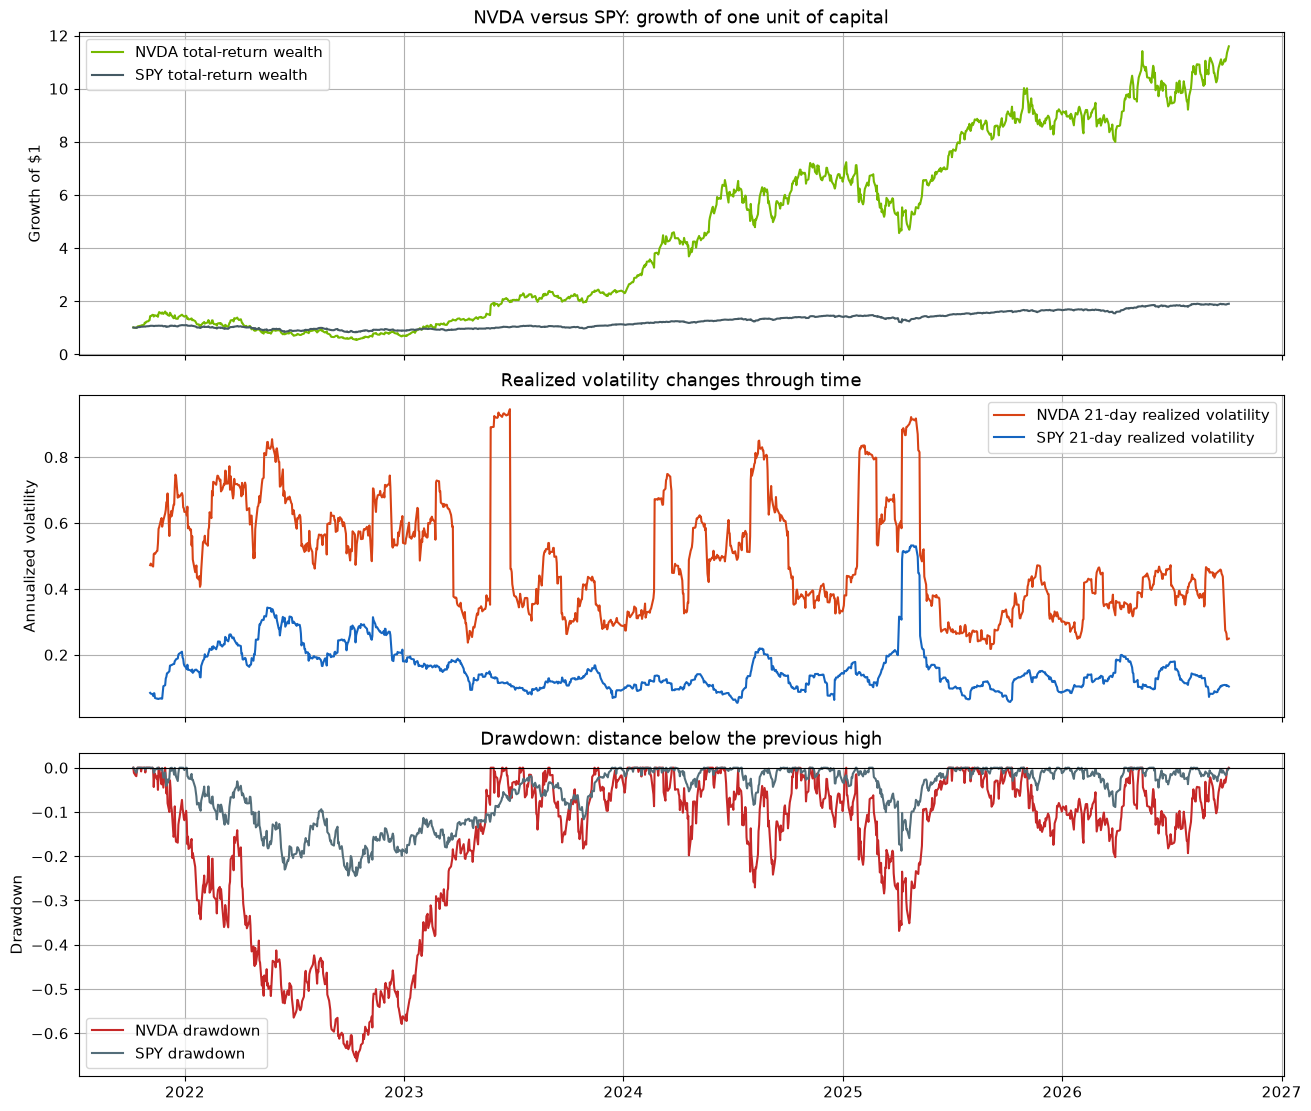

,NVDA,SPY
annualized return,62.65%,14.43%
annualized volatility,51.92%,17.16%
maximum drawdown,-66.34%,-24.50%
latest 63-day beta,1.95,n/a


Downloaded 1,254 daily observations from 2021-10-06 to 2026-10-05


In [2]:
import yfinance as yf

symbols = ['NVDA', 'SPY']
market = yf.download(symbols, period='5y', auto_adjust=True, progress=False, group_by='column')
if market.empty:
    raise RuntimeError('No market data returned. Check network access or provide a local OHLCV file.')

close = market['Close'].dropna()
returns = close.pct_change().dropna()
rolling_vol = returns.rolling(21).std() * np.sqrt(TRADING_DAYS)
wealth = (1 + returns).cumprod()
rolling_high = wealth.cummax()
drawdown = wealth / rolling_high - 1
beta = returns['NVDA'].rolling(63).cov(returns['SPY']) / returns['SPY'].rolling(63).var()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True, constrained_layout=True)
axes[0].plot(wealth['NVDA'], label='NVDA total-return wealth', color='#76b900')
axes[0].plot(wealth['SPY'], label='SPY total-return wealth', color='#455a64')
axes[0].set_title('NVDA versus SPY: growth of one unit of capital')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[1].plot(rolling_vol['NVDA'], label='NVDA 21-day realized volatility', color='#d84315')
axes[1].plot(rolling_vol['SPY'], label='SPY 21-day realized volatility', color='#1565c0')
axes[1].set_title('Realized volatility changes through time')
axes[1].set_ylabel('Annualized volatility')
axes[1].legend()
axes[2].plot(drawdown['NVDA'], label='NVDA drawdown', color='#c62828')
axes[2].plot(drawdown['SPY'], label='SPY drawdown', color='#546e7a')
axes[2].axhline(0, color='black', linewidth=.8)
axes[2].set_title('Drawdown: distance below the previous high')
axes[2].set_ylabel('Drawdown')
axes[2].legend()
plt.show()

summary = pd.DataFrame({
    'NVDA': [returns['NVDA'].mean() * TRADING_DAYS, returns['NVDA'].std() * np.sqrt(TRADING_DAYS), drawdown['NVDA'].min(), beta.iloc[-1]],
    'SPY': [returns['SPY'].mean() * TRADING_DAYS, returns['SPY'].std() * np.sqrt(TRADING_DAYS), drawdown['SPY'].min(), np.nan],
}, index=['annualized return', 'annualized volatility', 'maximum drawdown', 'latest 63-day beta'])
summary_display = pd.DataFrame(index=summary.index, columns=summary.columns, dtype=object)
for row in ['annualized return', 'annualized volatility', 'maximum drawdown']:
    summary_display.loc[row] = summary.loc[row].map(lambda value: f'{value:.2%}')
summary_display.loc['latest 63-day beta'] = summary.loc['latest 63-day beta'].map(lambda value: f'{value:.2f}' if np.isfinite(value) else 'n/a')
display(summary_display)
print(f'Downloaded {len(close):,} daily observations from {close.index.min().date()} to {close.index.max().date()}')

## Real-world relative-value test: NVDA versus SPY

This is a deliberately modest research signal, not a claim that NVDA and SPY are cointegrated. We estimate a rolling hedge ratio from past returns, construct a log-price spread, and trade only when the lagged z-score crosses a band. Positions are lagged by one day to avoid using today’s close before it is known, and turnover is charged at the visible fee/slippage rate.

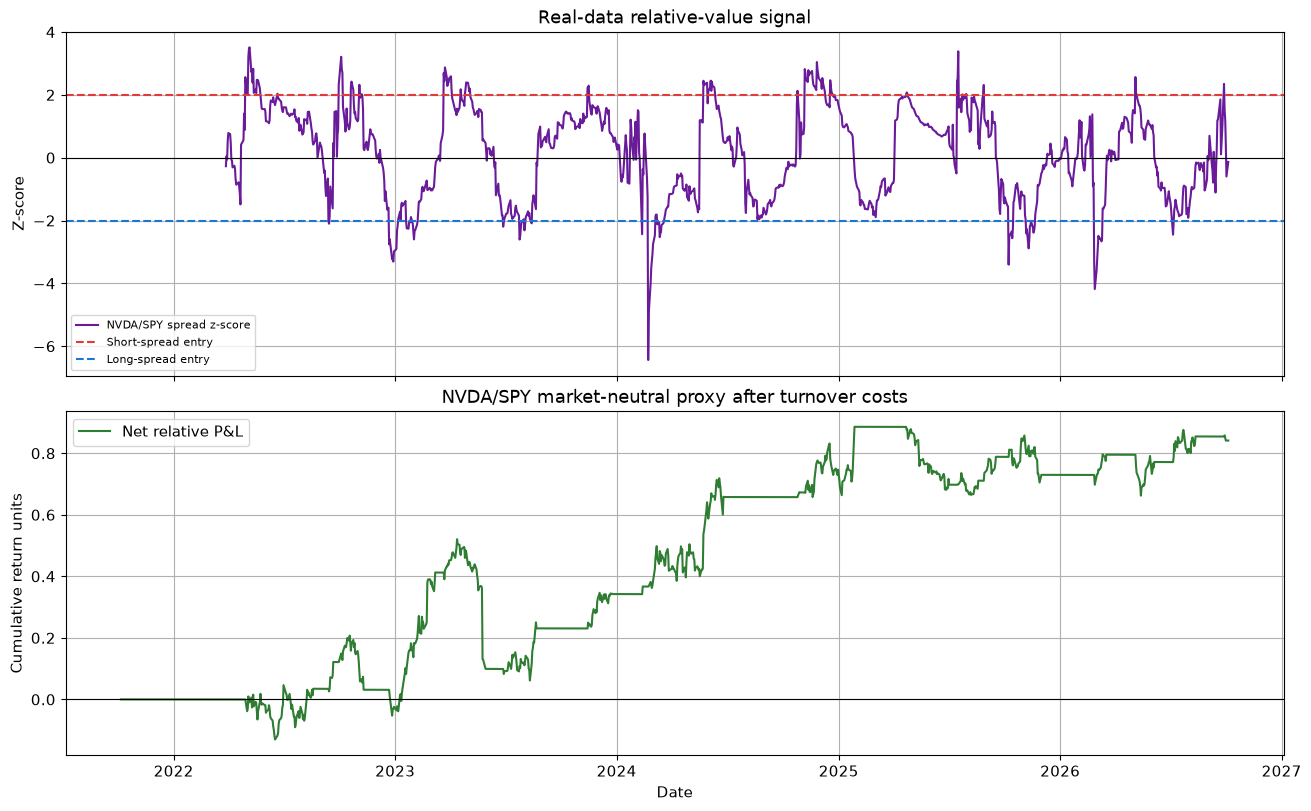

,NVDA/SPY
annualized Sharpe,0.640819
maximum drawdown,-0.459102
number of position changes,38.000000
average daily turnover,0.030303


In [3]:
log_close = np.log(close)
rolling_beta = returns['NVDA'].rolling(60).cov(returns['SPY']) / returns['SPY'].rolling(60).var()
spread = log_close['NVDA'] - rolling_beta * log_close['SPY']
spread_mean = spread.rolling(60).mean()
spread_std = spread.rolling(60).std()
zscore = (spread - spread_mean) / spread_std

position = pd.Series(0.0, index=close.index)
current = 0.0
for timestamp, z_value in zscore.items():
    if not np.isfinite(z_value):
        position.loc[timestamp] = current
    elif current == 0 and z_value > 2.0:
        current = -1.0
        position.loc[timestamp] = current
    elif current == 0 and z_value < -2.0:
        current = 1.0
        position.loc[timestamp] = current
    elif current != 0 and abs(z_value) < .5:
        current = 0.0
        position.loc[timestamp] = current
    else:
        position.loc[timestamp] = current

spread_return = returns['NVDA'] - rolling_beta.shift(1) * returns['SPY']
turnover = position.diff().abs().fillna(0)
net_pnl = position.shift(1).fillna(0) * spread_return - turnover * (FEE_BPS + SLIPPAGE_BPS) * 1e-4
relative_equity = net_pnl.fillna(0).cumsum()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, constrained_layout=True)
axes[0].plot(zscore, color='#6a1b9a', label='NVDA/SPY spread z-score')
axes[0].axhline(2, color='#e53935', linestyle='--', label='Short-spread entry')
axes[0].axhline(-2, color='#1976d2', linestyle='--', label='Long-spread entry')
axes[0].axhline(0, color='black', linewidth=.8)
axes[0].set_title('Real-data relative-value signal')
axes[0].set_ylabel('Z-score')
axes[0].legend(fontsize=8)
axes[1].plot(relative_equity, color='#2e7d32', label='Net relative P&L')
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].set_title('NVDA/SPY market-neutral proxy after turnover costs')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative return units')
axes[1].legend()
plt.show()

relative_metrics = pd.Series({
    'annualized Sharpe': annualized_sharpe(net_pnl.dropna()),
    'maximum drawdown': max_drawdown(relative_equity),
    'number of position changes': int((turnover > 0).sum()),
    'average daily turnover': turnover.mean(),
})
display(relative_metrics.to_frame('NVDA/SPY'))

## 1. Market microstructure: the book is a queue

A limit-order book is not just a list of prices. Orders wait in queues, and earlier orders at the same price get priority. We will show the **mid-price**, **spread**, **depth**, and **queue imbalance**:

$$QI_t = \frac{V^{bid}_t - V^{ask}_t}{V^{bid}_t + V^{ask}_t}.$$

A positive $QI$ means more displayed size on the bid side. That can indicate buying pressure, but it is not automatically a profitable signal: displayed orders can cancel, and taking liquidity pays spread plus slippage.

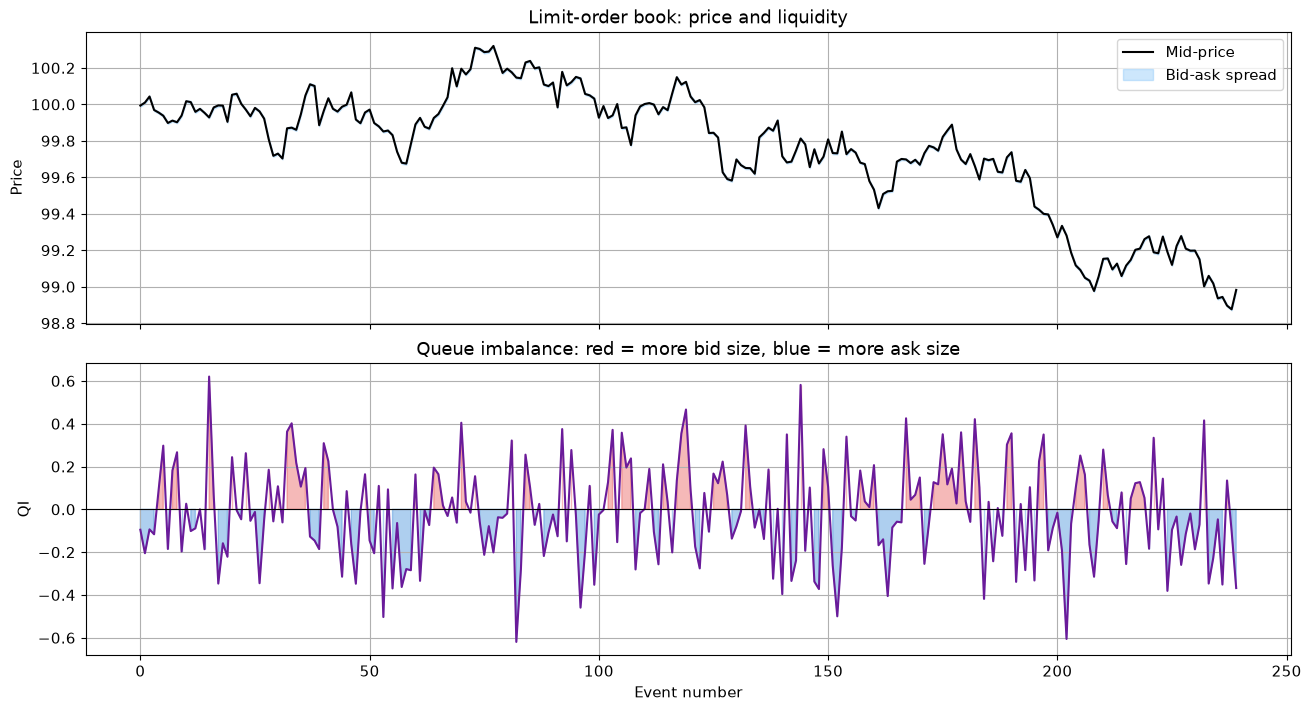

Median spread: 1.13 bps
Median displayed depth: 28.1 units


In [4]:
# Synthetic level-2 snapshots with spread, depth, and queue imbalance.
steps = 240
mid = 100 * np.exp(np.cumsum(rng.normal(0, 0.0007, steps)))
spread = 0.01 + 0.002 * np.abs(rng.normal(size=steps))
bid = mid - spread / 2
ask = mid + spread / 2
bid_depth = rng.lognormal(mean=3.3, sigma=.35, size=steps)
ask_depth = rng.lognormal(mean=3.3, sigma=.35, size=steps)
queue_imbalance = (bid_depth - ask_depth) / (bid_depth + ask_depth)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
axes[0].plot(mid, color='black', label='Mid-price')
axes[0].fill_between(np.arange(steps), bid, ask, color='#90caf9', alpha=.45, label='Bid-ask spread')
axes[0].set_title('Limit-order book: price and liquidity')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[1].plot(queue_imbalance, color='#6a1b9a', label='Queue imbalance')
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].fill_between(np.arange(steps), queue_imbalance, 0, where=queue_imbalance >= 0, color='#e53935', alpha=.35)
axes[1].fill_between(np.arange(steps), queue_imbalance, 0, where=queue_imbalance < 0, color='#1976d2', alpha=.35)
axes[1].set_title('Queue imbalance: red = more bid size, blue = more ask size')
axes[1].set_xlabel('Event number')
axes[1].set_ylabel('QI')
plt.show()

print(f'Median spread: {np.median(spread / mid) * 10000:.2f} bps')
print(f'Median displayed depth: {np.median((bid_depth + ask_depth) / 2):.1f} units')

## 2. Derivatives: use a surface when three dimensions matter

A single volatility number is a useful Black-Scholes baseline, but listed options often show a **smile/skew**: implied volatility varies with strike and maturity. Here the third dimension is genuinely useful, so the next cell creates an interactive 3D Plotly surface.

The model is still simplified: it omits stochastic volatility, jumps, dividends, rates curves, early exercise, and bid/ask valuation adjustments. Those are model-risk items, not details to hide.

In [5]:
# A volatility smile: higher implied volatility away from the at-the-money strike.
spot = 100.0
rate = .03
strikes = np.linspace(70, 130, 45)
maturities = np.linspace(.05, 2.0, 35)
strike_grid, maturity_grid = np.meshgrid(strikes, maturities)
log_moneyness = np.log(strike_grid / spot)
implied_vol = .18 + .10 * log_moneyness**2 + .035 * np.maximum(log_moneyness, 0)
call_surface = bs_call(spot, strike_grid, rate, implied_vol, maturity_grid)

surface_figure = go.Figure(go.Surface(
    x=strikes,
    y=maturities,
    z=call_surface,
    surfacecolor=implied_vol,
    colorscale='Viridis',
    colorbar={'title': 'Implied vol'},
    hovertemplate='Strike %{x:.1f}<br>Time %{y:.2f}y<br>Call price %{z:.2f}<extra></extra>',
))
surface_figure.update_layout(
    title='Interactive option value under a volatility smile',
    scene=dict(xaxis_title='Strike', yaxis_title='Time to expiry', zaxis_title='Call value'),
    height=650,
)
surface_figure.show()

atm_index = np.argmin(np.abs(strikes - spot))
print(f'ATM one-year call value: {call_surface[np.argmin(np.abs(maturities - 1.0)), atm_index]:.2f}')

ATM one-year call value: 8.77


## 3. Statistical arbitrage: separate research from evaluation

Pairs trading is easy to overstate if the same data is used to choose thresholds and report performance. We use the first 60% as a **research period** and the last 40% as a rough **evaluation period**. The trade accounting subtracts exchange fees and a simple adverse price movement for market impact.

The important question is not “does the curve go up?” but “does it survive costs and a time period that was not used to choose the idea?”

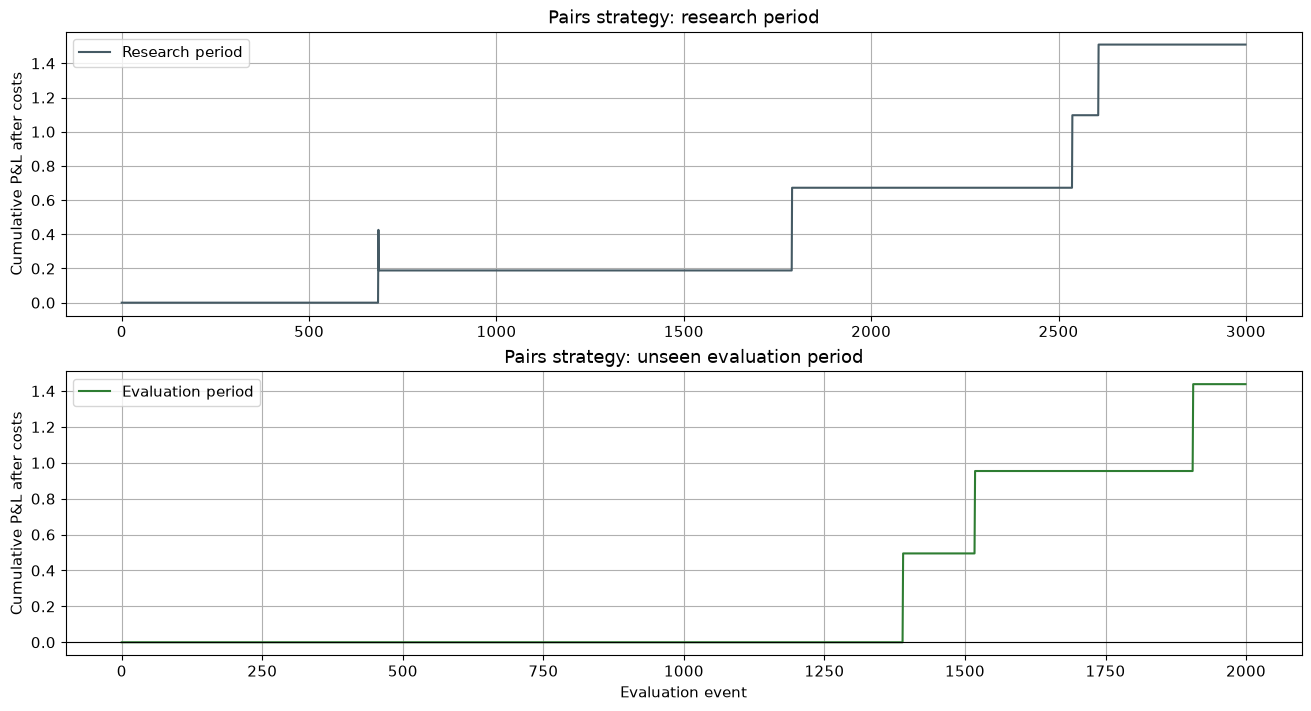

,research,evaluation
annualized Sharpe,0.482599,0.614825
maximum drawdown,-0.237432,0.000000
signal events,8.000000,6.000000


Interpretation: a research result is not evidence of a deployable strategy; the evaluation period and transaction-cost assumptions are the first reality checks.


In [6]:
pairs = synthetic_ticks(n=5000, seed=SEED)
split = int(len(pairs) * TRAIN_FRACTION)
train = pairs[:split]
test = pairs[split:]

# Thresholds are fixed before looking at evaluation results.
train_result = pairs_backtest(train, fee_bps=FEE_BPS + SLIPPAGE_BPS, entry=1.5, exit=.5)
test_result = pairs_backtest(test, fee_bps=FEE_BPS + SLIPPAGE_BPS, entry=1.5, exit=.5)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False, constrained_layout=True)
axes[0].plot(train_result['equity'], color='#455a64', label='Research period')
axes[0].set_title('Pairs strategy: research period')
axes[0].set_ylabel('Cumulative P&L after costs')
axes[0].legend()
axes[1].plot(test_result['equity'], color='#2e7d32', label='Evaluation period')
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].set_title('Pairs strategy: unseen evaluation period')
axes[1].set_xlabel('Evaluation event')
axes[1].set_ylabel('Cumulative P&L after costs')
axes[1].legend()
plt.show()

metrics = pd.DataFrame({
    'research': [annualized_sharpe(train_result['pnl']), max_drawdown(train_result['equity']), len(train_result['signals'])],
    'evaluation': [annualized_sharpe(test_result['pnl']), max_drawdown(test_result['equity']), len(test_result['signals'])],
}, index=['annualized Sharpe', 'maximum drawdown', 'signal events'])
display(metrics)
print('Interpretation: a research result is not evidence of a deployable strategy; the evaluation period and transaction-cost assumptions are the first reality checks.')

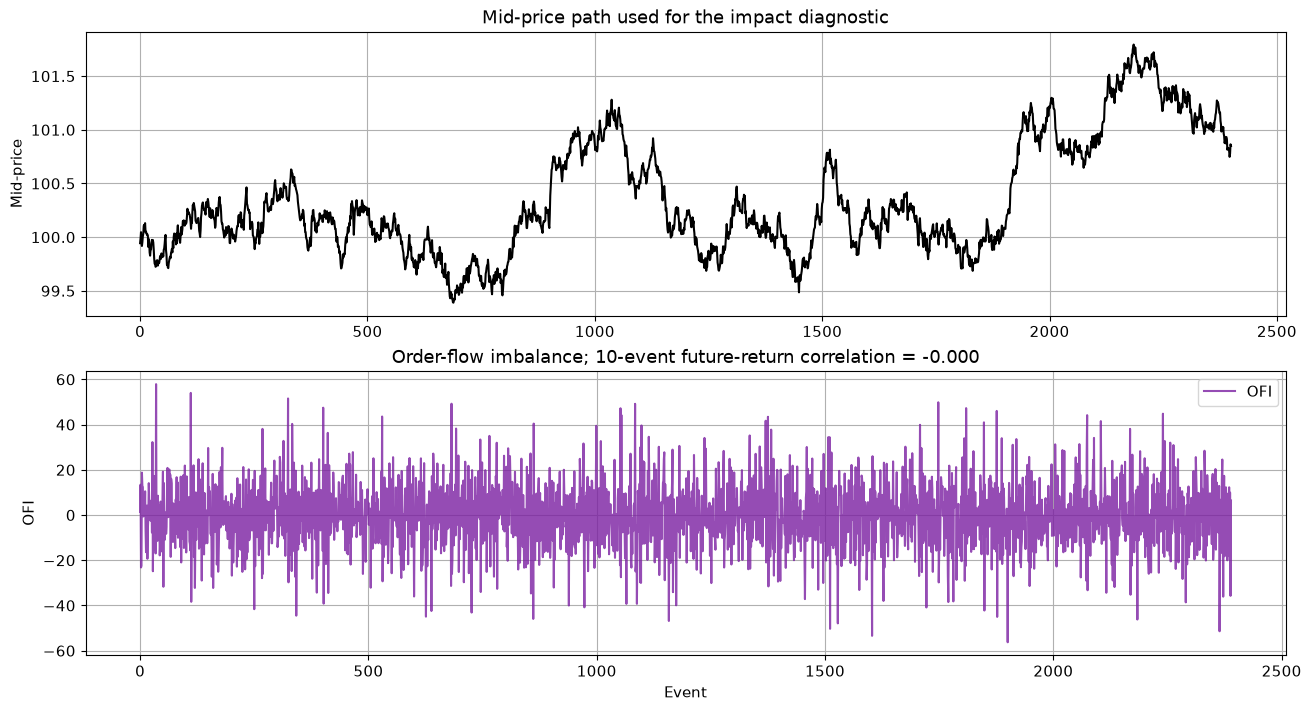

OFI / future-return correlation: -0.000


In [7]:
tick_count = 2400
mid_prices = 100.0 * np.exp(np.cumsum(rng.normal(0, .0005, tick_count)))
bid_prices = mid_prices - .005
ask_prices = mid_prices + .005
bid_sizes = rng.lognormal(3.0, .45, tick_count)
ask_sizes = rng.lognormal(3.0, .45, tick_count)
ofi = extract_ofi(bid_prices, bid_sizes, ask_prices, ask_sizes)
horizon = 10
future_return = mid_prices[horizon:] / mid_prices[:-horizon] - 1
leading_ofi = ofi[:len(future_return)]
ofi_correlation = np.corrcoef(leading_ofi, future_return)[0, 1]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True)
axes[0].plot(mid_prices, color='black')
axes[0].set_title('Mid-price path used for the impact diagnostic')
axes[0].set_ylabel('Mid-price')
axes[1].plot(leading_ofi, color='#7b1fa2', alpha=.8, label='OFI')
axes[1].set_title(f'Order-flow imbalance; 10-event future-return correlation = {ofi_correlation:.3f}')
axes[1].set_xlabel('Event')
axes[1].set_ylabel('OFI')
axes[1].legend()
plt.show()
print(f'OFI / future-return correlation: {ofi_correlation:.3f}')

## Research checklist

Before treating any result as useful, ask:

- Did the signal survive fees, spread, latency, and market impact?
- Were thresholds selected without looking at the evaluation period?
- Is the effect stable across assets, venues, regimes, and random seeds?
- Are the statistical errors robust to dependence and multiple testing?
- Can the result be explained by a known mechanism, or is it only curve fitting?

**References:** Black & Scholes (1973); Engle & Granger (1987); Gatev, Goetzmann & Rouwenhorst (2006); Kyle (1985); Hasbrouck (1991); Cont, Kukanov & Stoikov (2014); Avellaneda & Stoikov (2008).

## 4. Microstructure: does order flow lead price?

OFI summarizes changes in bid and ask size. Following Cont, Kukanov & Stoikov, we can test whether OFI leads a short-horizon price change instead of merely drawing a colorful chart. This is a correlation diagnostic, not a causal claim.

We also report a simple out-of-sample correlation. In a real study, you would add venue controls, event-time sampling, spread, volatility, autocorrelation-robust errors, and a purged validation design.

## 5. Multi-asset portfolio: equities, bonds, commodities, and an option overlay

A professional portfolio is not one stock. We use public daily proxies:

- **NVDA, SPY:** equities
- **TLT:** long-duration US Treasury exposure
- **GLD, USO:** gold and oil commodity proxies
- **NVDA call overlay:** a clearly labeled model-based derivative sleeve, valued with Black-Scholes rather than pretending an ETF is an option

For weights $w$, expected return $\mu$, and covariance matrix $\Sigma$:

$$E[R_p] = w^T\mu, \qquad \sigma_p = \sqrt{w^T\Sigma w}, \qquad SR_p = \frac{w^T\mu-r_f}{\sqrt{w^T\Sigma w}}.$$

The optimizer below is long-only, fully invested, and capped per asset. That is a governance choice, not a universal truth.

In [8]:
import yfinance as yf

asset_map = {
    'NVDA': 'equity',
    'SPY': 'equity',
    'TLT': 'bonds',
    'GLD': 'gold',
    'USO': 'oil',
}
asset_data = yf.download(list(asset_map), period='5y', auto_adjust=True, progress=False, group_by='column')
asset_close = asset_data['Close'].dropna()
asset_returns = asset_close.pct_change().dropna()
asset_mu = asset_returns.mean() * TRADING_DAYS
asset_cov = asset_returns.cov() * TRADING_DAYS
asset_names = asset_returns.columns.tolist()

# Model-based NVDA call overlay: delta exposure is shown separately from cash assets.
# This is not a quoted option-chain price and must not be treated as executable.
call_vol = asset_returns['NVDA'].rolling(63).std().iloc[-1] * np.sqrt(TRADING_DAYS)
call_spot = float(asset_close['NVDA'].iloc[-1])
call_strike = call_spot * 1.05
call_value = bs_call(call_spot, call_strike, RISK_FREE_RATE, call_vol, 0.5)

print(f'Assets: {", ".join(asset_names)}')
print(f'NVDA model call: spot={call_spot:.2f}, strike={call_strike:.2f}, vol={call_vol:.1%}, value={call_value:.2f}')
display(pd.DataFrame({'annual return': asset_mu, 'annual volatility': np.sqrt(np.diag(asset_cov))}).style.format('{:.2%}'))

Assets: GLD, NVDA, SPY, TLT, USO
NVDA model call: spot=238.90, strike=250.84, vol=38.6%, value=22.99


,annual return,annual volatility
Ticker,,
GLD,18.55%,18.91%
NVDA,62.65%,51.92%
SPY,14.43%,17.16%
TLT,-7.78%,15.69%
USO,26.77%,37.66%


## 6. Markowitz allocation and efficient frontier

The classical Markowitz problem is:

$$\min_w \; w^T\Sigma w \quad \text{subject to} \quad \mathbf{1}^T w=1,\; w^T\mu=\mu^*,\; 0\le w_i\le w_{max}.$$

We trace many target returns. The curve shows the best volatility the historical sample found for each target. It is useful for understanding diversification, but expected returns are noisy and the frontier is highly sensitive to estimation error. A production optimizer would use shrinkage, robust constraints, turnover penalties, and scenario analysis.

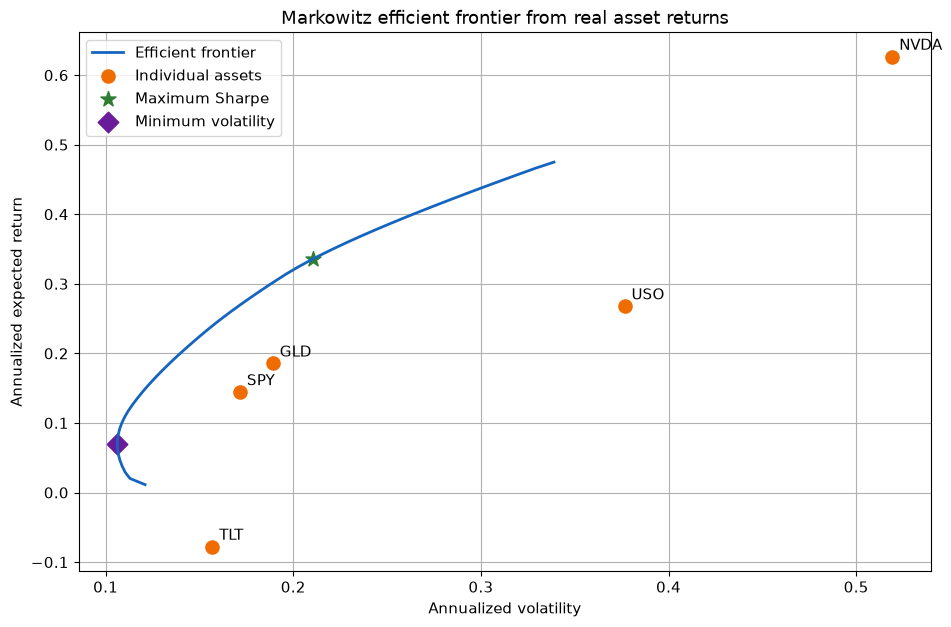

,minimum volatility,maximum Sharpe
GLD,18.1%,49.9%
NVDA,0.0%,30.3%
SPY,30.6%,0.0%
TLT,42.0%,0.0%
USO,9.3%,19.8%


Max-Sharpe portfolio: return=33.56%, volatility=21.04%, Sharpe=1.41


In [9]:
n_assets = len(asset_names)
max_weight = 0.60
bounds = [(0.0, max_weight)] * n_assets
initial = np.full(n_assets, 1.0 / n_assets)
ones = np.ones(n_assets)

def portfolio_return(weights):
    return float(weights @ asset_mu.values)

def portfolio_vol(weights):
    return float(np.sqrt(weights @ asset_cov.values @ weights))

def solve_min_vol(target_return):
    constraints = [
        {'type': 'eq', 'fun': lambda weights: weights.sum() - 1.0},
        {'type': 'eq', 'fun': lambda weights: portfolio_return(weights) - target_return},
    ]
    return minimize(portfolio_vol, initial, method='SLSQP', bounds=bounds, constraints=constraints, options={'maxiter': 1000, 'ftol': 1e-12})

targets = np.linspace(asset_mu.min(), asset_mu.max(), 80)
frontier = []
frontier_weights = []
for target in targets:
    solution = solve_min_vol(float(target))
    if solution.success:
        frontier.append((portfolio_return(solution.x), portfolio_vol(solution.x)))
        frontier_weights.append(solution.x)
frontier = np.asarray(frontier)

sharpe_solution = minimize(
    lambda weights: -(portfolio_return(weights) - RISK_FREE_RATE) / (portfolio_vol(weights) + 1e-12),
    initial,
    method='SLSQP', bounds=bounds,
    constraints={'type': 'eq', 'fun': lambda weights: weights.sum() - 1.0},
)
max_sharpe_weights = sharpe_solution.x
min_vol_solution = minimize(
    portfolio_vol, initial, method='SLSQP', bounds=bounds,
    constraints={'type': 'eq', 'fun': lambda weights: weights.sum() - 1.0},
)
min_vol_weights = min_vol_solution.x

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(frontier[:, 1], frontier[:, 0], color='#1565c0', linewidth=2, label='Efficient frontier')
ax.scatter(np.sqrt(np.diag(asset_cov)), asset_mu, s=90, color='#ef6c00', label='Individual assets')
for name, vol, ret in zip(asset_names, np.sqrt(np.diag(asset_cov)), asset_mu):
    ax.annotate(name, (vol, ret), xytext=(5, 5), textcoords='offset points')
ax.scatter(portfolio_vol(max_sharpe_weights), portfolio_return(max_sharpe_weights), color='#2e7d32', s=130, marker='*', label='Maximum Sharpe')
ax.scatter(portfolio_vol(min_vol_weights), portfolio_return(min_vol_weights), color='#6a1b9a', s=110, marker='D', label='Minimum volatility')
ax.set(title='Markowitz efficient frontier from real asset returns', xlabel='Annualized volatility', ylabel='Annualized expected return')
ax.legend(); plt.show()

weight_table = pd.DataFrame({'minimum volatility': min_vol_weights, 'maximum Sharpe': max_sharpe_weights}, index=asset_names)
display(weight_table.style.format('{:.1%}'))
print(f'Max-Sharpe portfolio: return={portfolio_return(max_sharpe_weights):.2%}, volatility={portfolio_vol(max_sharpe_weights):.2%}, Sharpe={(portfolio_return(max_sharpe_weights)-RISK_FREE_RATE)/portfolio_vol(max_sharpe_weights):.2f}')

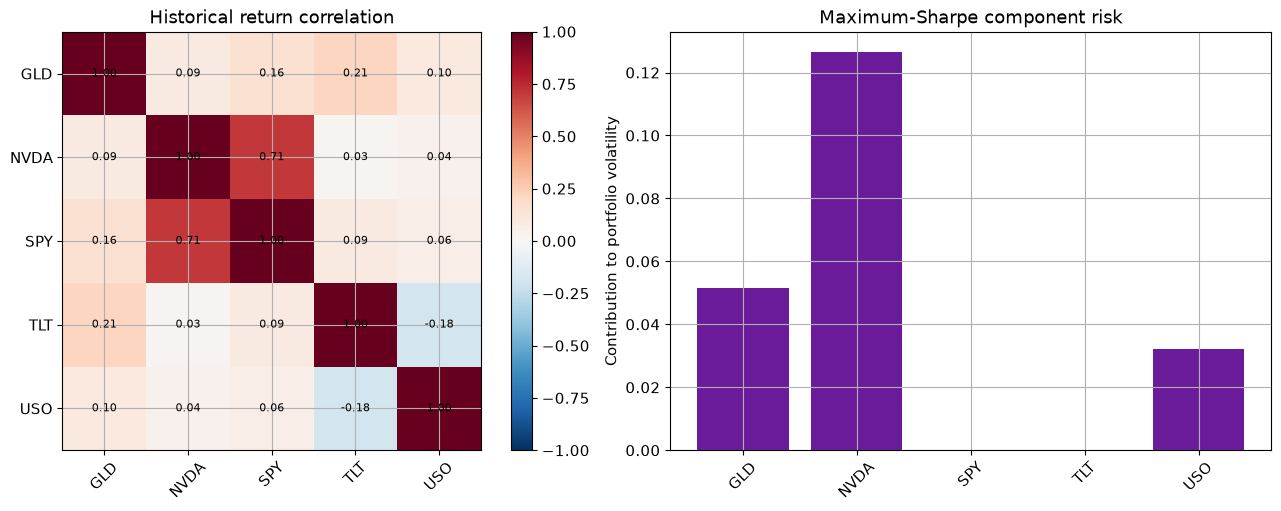

,weight,marginal risk contribution,component risk contribution
GLD,49.85%,10.36%,5.17%
NVDA,30.34%,41.74%,12.66%
SPY,0.00%,10.66%,0.00%
TLT,0.00%,0.83%,0.00%
USO,19.81%,16.20%,3.21%


,portfolio shock return
equity shock,-12.07%
inflation shock,3.40%
growth shock,-15.03%


In [10]:
# Audit the maximum-Sharpe portfolio instead of reporting only its weights.
weights = pd.Series(max_sharpe_weights, index=asset_names)
portfolio_variance = float(weights.values @ asset_cov.values @ weights.values)
marginal_contribution = asset_cov.values @ weights.values / np.sqrt(portfolio_variance)
component_contribution = weights.values * marginal_contribution
risk_audit = pd.DataFrame({
    'weight': weights,
    'marginal risk contribution': marginal_contribution,
    'component risk contribution': component_contribution,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
correlation = asset_returns.corr()
image = axes[0].imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(n_assets), asset_names, rotation=45)
axes[0].set_yticks(range(n_assets), asset_names)
axes[0].set_title('Historical return correlation')
for row in range(n_assets):
    for col in range(n_assets):
        axes[0].text(col, row, f'{correlation.iloc[row, col]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axes[0], fraction=.046)
axes[1].bar(asset_names, component_contribution, color='#6a1b9a')
axes[1].set_title('Maximum-Sharpe component risk')
axes[1].set_ylabel('Contribution to portfolio volatility')
axes[1].tick_params(axis='x', rotation=45)
plt.show()

display(risk_audit.style.format('{:.2%}'))

stress_returns = pd.DataFrame({
    'equity shock': {'NVDA': -.30, 'SPY': -.15, 'TLT': .05, 'GLD': .02, 'USO': -.20},
    'inflation shock': {'NVDA': -.15, 'SPY': -.08, 'TLT': -.12, 'GLD': .08, 'USO': .20},
    'growth shock': {'NVDA': -.25, 'SPY': -.12, 'TLT': .08, 'GLD': -.05, 'USO': -.25},
}).reindex(asset_names)
stress_pnl = stress_returns.mul(weights, axis=0).sum()
display(pd.DataFrame({'portfolio shock return': stress_pnl}).style.format('{:.2%}'))

## 8. How to read this like a quant

The dashboard is now a decision surface, not a collection of pretty charts:

- **Markowitz** answers how historical return and covariance estimates trade off, subject to explicit constraints.
- **Risk contribution** answers which positions actually drive volatility.
- **Stress tests** answer whether diversification survives a named economic shock.
- **Credit loss** separates ordinary expected loss from tail loss caused by correlated defaults.
- **Derivatives** show nonlinear exposure and why volatility assumptions matter.
- **Microstructure and stat-arb** are only credible after timestamp alignment, realistic execution, costs, and out-of-sample testing.

For production research, the next controls are shrinkage covariance, Bayesian/robust expected returns, volatility targeting, turnover penalties, regime-conditioned stress scenarios, option-chain calibration, credit migration, and independent model validation. Historical estimates are evidence, not truth.

## 7. Credit risk: probability of default, LGD, and portfolio loss

For exposure $i$:

$$EL_i = PD_i \times LGD_i \times EAD_i,$$

where **PD** is probability of default, **LGD** is loss given default, and **EAD** is exposure at default. Expected loss is not a stress loss. To model concentration and default clustering, this example uses a one-factor Gaussian copula:

$$A_i = \sqrt{\rho_i}F + \sqrt{1-\rho_i}\epsilon_i,$$ 

and default occurs when $A_i < \Phi^{-1}(PD_i)$. This is related to the Vasicek/ASRF credit portfolio framework used in regulatory capital modeling. It is still a simplified model: real credit work needs ratings migration, recovery timing, wrong-way risk, collateral, netting, and calibrated dependence.

,counterparty,pd_1y,lgd,ead_millions,asset_corr,expected_loss_m
0,A,0.40%,35%,$40.0m,20%,$0.056m
1,B,1.20%,40%,$25.0m,25%,$0.120m
2,C,2.50%,45%,$18.0m,30%,$0.203m
3,D,6.00%,50%,$12.0m,35%,$0.360m
4,E,12.00%,55%,$8.0m,40%,$0.528m
5,F,22.00%,60%,$5.0m,45%,$0.660m


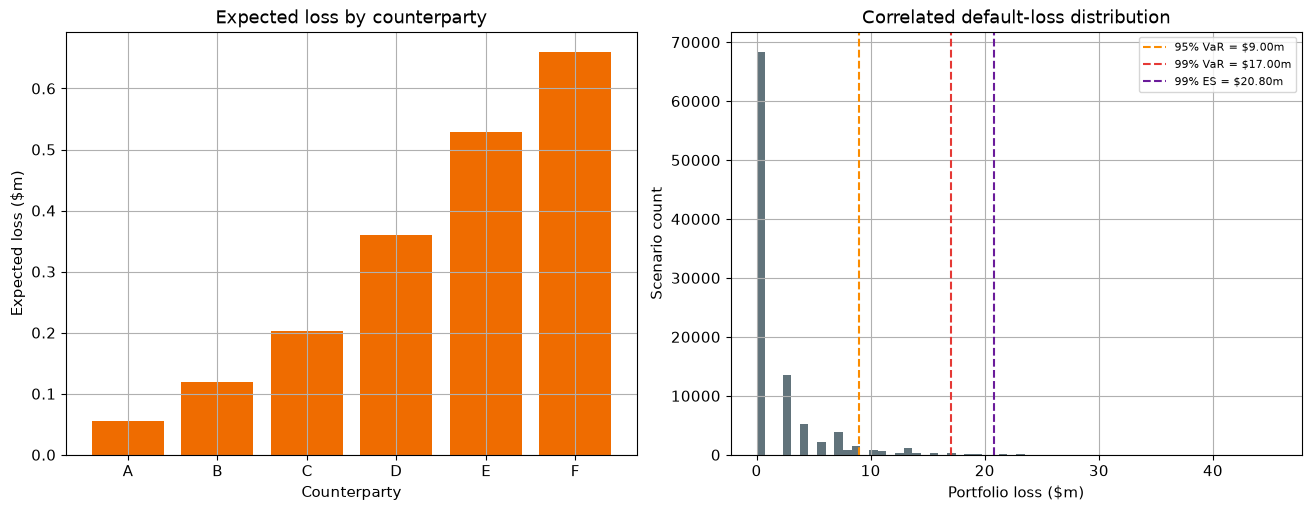

,credit portfolio
expected loss ($m),1.909374
95% VaR ($m),9.000000
95% expected shortfall ($m),12.982184
99% VaR ($m),17.000000
99% expected shortfall ($m),20.804965


In [11]:
credit_book = pd.DataFrame({
    'counterparty': ['A', 'B', 'C', 'D', 'E', 'F'],
    'pd_1y': [0.004, 0.012, 0.025, 0.060, 0.120, 0.220],
    'lgd': [0.35, 0.40, 0.45, 0.50, 0.55, 0.60],
    'ead_millions': [40, 25, 18, 12, 8, 5],
    'asset_corr': [0.20, 0.25, 0.30, 0.35, 0.40, 0.45],
})
credit_book['expected_loss_m'] = credit_book['pd_1y'] * credit_book['lgd'] * credit_book['ead_millions']
display(credit_book.style.format({'pd_1y': '{:.2%}', 'lgd': '{:.0%}', 'ead_millions': '${:.1f}m', 'expected_loss_m': '${:.3f}m', 'asset_corr': '{:.0%}'}))

scenarios = 100_000
systematic_factor = rng.normal(size=scenarios)
idiosyncratic = rng.normal(size=(scenarios, len(credit_book)))
asset_value = systematic_factor[:, None] * np.sqrt(credit_book['asset_corr'].to_numpy()) + idiosyncratic * np.sqrt(1 - credit_book['asset_corr'].to_numpy())
thresholds = norm.ppf(credit_book['pd_1y'].to_numpy())
defaults = asset_value < thresholds
losses = (defaults * (credit_book['lgd'].to_numpy() * credit_book['ead_millions'].to_numpy())).sum(axis=1)
expected_loss = losses.mean()
credit_var_95 = np.quantile(losses, .95)
credit_var_99 = np.quantile(losses, .99)
credit_cvar_95 = losses[losses >= credit_var_95].mean()
credit_cvar_99 = losses[losses >= credit_var_99].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].bar(credit_book['counterparty'], credit_book['expected_loss_m'], color='#ef6c00')
axes[0].set(title='Expected loss by counterparty', xlabel='Counterparty', ylabel='Expected loss ($m)')
axes[1].hist(losses, bins=60, color='#455a64', alpha=.85)
axes[1].axvline(credit_var_95, color='#fb8c00', linestyle='--', label=f'95% VaR = ${credit_var_95:.2f}m')
axes[1].axvline(credit_var_99, color='#e53935', linestyle='--', label=f'99% VaR = ${credit_var_99:.2f}m')
axes[1].axvline(credit_cvar_99, color='#6a1b9a', linestyle='--', label=f'99% ES = ${credit_cvar_99:.2f}m')
axes[1].set(title='Correlated default-loss distribution', xlabel='Portfolio loss ($m)', ylabel='Scenario count')
axes[1].legend(fontsize=8)
plt.show()

credit_metrics = pd.Series({'expected loss ($m)': expected_loss, '95% VaR ($m)': credit_var_95, '95% expected shortfall ($m)': credit_cvar_95, '99% VaR ($m)': credit_var_99, '99% expected shortfall ($m)': credit_cvar_99})
display(credit_metrics.to_frame('credit portfolio'))

## 9. Which assets should weigh more?

There is no universally correct “optimal weight.” Each allocation theory optimizes a different belief:

- **Equal weight:** simple diversification; ignores volatility and correlation.
- **Inverse volatility:** puts less weight in assets that move more; ignores correlation.
- **Risk parity:** chooses weights so each asset contributes roughly equally to portfolio volatility.
- **Minimum volatility:** minimizes historical covariance-based risk.
- **Maximum Sharpe:** maximizes estimated excess return per unit of historical risk.

For a portfolio with volatility $\sigma_p$, component risk contribution is:

$$RC_i = \frac{w_i(\Sigma w)_i}{\sigma_p}.$$

The comparison below is the honest answer to “what should weigh more?”: it depends on whether the objective is simplicity, balanced risk, minimum volatility, or historical reward-to-risk.

,equal weight,inverse volatility,risk parity,minimum volatility,maximum Sharpe
GLD,20.0%,24.0%,22.7%,18.1%,49.9%
NVDA,20.0%,8.7%,7.7%,0.0%,30.3%
SPY,20.0%,26.4%,21.5%,30.6%,0.0%
TLT,20.0%,28.9%,33.5%,42.0%,0.0%
USO,20.0%,12.0%,14.6%,9.3%,19.8%


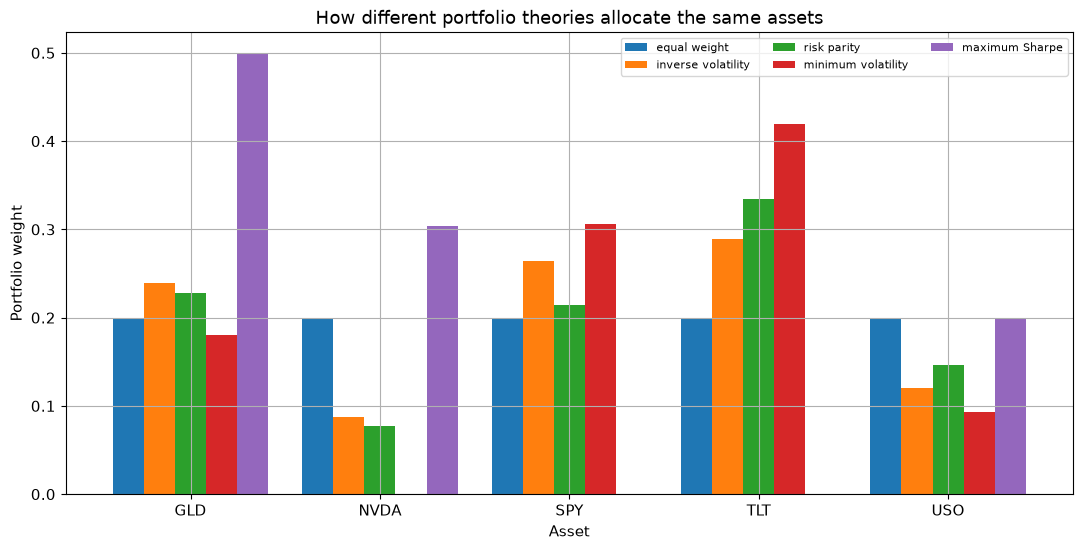

,annualized return,annualized volatility,Sharpe,95% VaR,99% VaR,95% expected shortfall,99% expected shortfall,maximum drawdown
equal weight,22.93%,16.67%,1.38,1.58%,2.67%,2.21%,3.28%,-33.90%
inverse volatility,14.70%,12.50%,1.18,1.22%,1.98%,1.69%,2.48%,-25.09%
risk parity,13.45%,12.15%,1.11,1.18%,1.92%,1.63%,2.36%,-24.69%
minimum volatility,7.01%,10.62%,0.66,1.07%,1.70%,1.45%,2.08%,-22.90%
maximum Sharpe,33.56%,21.04%,1.60,1.95%,3.33%,2.80%,4.20%,-82.78%


Reading the table: VaR is the loss threshold exceeded on roughly 5% or 1% of historical days. Expected shortfall is the average loss in that tail. Maximum drawdown is the worst peak-to-trough historical decline.


In [12]:
def risk_contributions(weights):
    weights = np.asarray(weights)
    volatility = portfolio_vol(weights)
    return weights * (asset_cov.values @ weights) / (volatility + 1e-12)

def risk_parity_objective(weights):
    contributions = risk_contributions(weights)
    target = contributions.sum() / len(contributions)
    return float(((contributions - target) ** 2).sum())

# Four allocation theories plus the two constrained optimizers already computed above.
equal_weights = np.full(n_assets, 1.0 / n_assets)
inverse_vol_weights = 1 / np.sqrt(np.diag(asset_cov))
inverse_vol_weights /= inverse_vol_weights.sum()
risk_parity_solution = minimize(
    risk_parity_objective,
    equal_weights,
    method='SLSQP',
    bounds=bounds,
    constraints={'type': 'eq', 'fun': lambda weights: weights.sum() - 1.0},
    options={'maxiter': 2000, 'ftol': 1e-12},
)
risk_parity_weights = risk_parity_solution.x

allocation_weights = pd.DataFrame({
    'equal weight': equal_weights,
    'inverse volatility': inverse_vol_weights,
    'risk parity': risk_parity_weights,
    'minimum volatility': min_vol_weights,
    'maximum Sharpe': max_sharpe_weights,
}, index=asset_names)
display(allocation_weights.style.format('{:.1%}'))

fig, ax = plt.subplots(figsize=(13, 6))
allocation_weights.plot(kind='bar', ax=ax, width=.82)
ax.set_title('How different portfolio theories allocate the same assets')
ax.set_ylabel('Portfolio weight')
ax.set_xlabel('Asset')
ax.legend(ncol=3, fontsize=8)
plt.xticks(rotation=0)
plt.show()

def portfolio_risk_metrics(weights):
    daily_returns = asset_returns @ weights
    losses = -daily_returns
    var_95 = float(np.quantile(losses, .95))
    var_99 = float(np.quantile(losses, .99))
    expected_shortfall_95 = float(losses[losses >= var_95].mean())
    expected_shortfall_99 = float(losses[losses >= var_99].mean())
    equity = (1 + daily_returns).cumprod()
    return {
        'annualized return': daily_returns.mean() * TRADING_DAYS,
        'annualized volatility': daily_returns.std(ddof=1) * np.sqrt(TRADING_DAYS),
        'Sharpe': annualized_sharpe(daily_returns),
        '95% VaR': var_95,
        '99% VaR': var_99,
        '95% expected shortfall': expected_shortfall_95,
        '99% expected shortfall': expected_shortfall_99,
        'maximum drawdown': max_drawdown(equity),
    }

allocation_metrics = pd.DataFrame({name: portfolio_risk_metrics(allocation_weights[name].values) for name in allocation_weights.columns}).T
allocation_display = allocation_metrics.copy().astype(object)
percent_columns = [column for column in allocation_metrics.columns if column != 'Sharpe']
for column in percent_columns:
    allocation_display[column] = allocation_metrics[column].map(lambda value: f'{value:.2%}')
allocation_display['Sharpe'] = allocation_metrics['Sharpe'].map(lambda value: f'{value:.2f}')
display(allocation_display)

print('Reading the table: VaR is the loss threshold exceeded on roughly 5% or 1% of historical days. Expected shortfall is the average loss in that tail. Maximum drawdown is the worst peak-to-trough historical decline.')

## 10. CIO-style allocation: a broader real portfolio

A professional allocator does not maximize the best-looking historical return without controls. The broader sleeve below contains liquid proxies for:

- **Equities:** US large-cap, Nasdaq, small-cap, international, emerging markets, healthcare, financials, energy, semiconductors, and NVDA.
- **Rates and credit:** long Treasuries, intermediate Treasuries, short Treasuries, investment-grade credit, high yield, and TIPS.
- **Real assets:** gold, silver, broad commodities, oil, and managed futures.

The optimizer uses a **research period** to estimate inputs and an **unseen evaluation period** to measure results. It shrinks the covariance matrix toward its diagonal, shrinks expected returns toward a prior, caps individual positions, caps sleeves, and penalizes concentration, downside volatility, and historical drawdown. This is a transparent research approximation, not a claim to reproduce any proprietary Citadel or Jane Street portfolio.

In [13]:
broad_universe = {
    'SPY': 'US equity', 'QQQ': 'US growth', 'IWM': 'US small cap', 'EFA': 'developed ex-US',
    'EEM': 'emerging markets', 'VNQ': 'real estate', 'XLE': 'energy equity', 'XLV': 'healthcare',
    'XLF': 'financials', 'SMH': 'semiconductors', 'NVDA': 'single-name equity',
    'TLT': 'long Treasuries', 'IEF': 'intermediate Treasuries', 'SHY': 'short Treasuries',
    'LQD': 'investment-grade credit', 'HYG': 'high yield credit', 'TIP': 'inflation-linked bonds',
    'GLD': 'gold', 'SLV': 'silver', 'DBC': 'broad commodities', 'USO': 'oil', 'DBMF': 'managed futures',
}

broad_raw = yf.download(list(broad_universe), period='10y', auto_adjust=True, progress=False, group_by='column')
broad_close = broad_raw['Close'].dropna(axis=1, how='all').dropna()
broad_returns = broad_close.pct_change().dropna()
broad_names = broad_returns.columns.tolist()
broad_classes = pd.Series({name: broad_universe[name] for name in broad_names})

split = int(len(broad_returns) * TRAIN_FRACTION)
broad_train = broad_returns.iloc[:split]
broad_test = broad_returns.iloc[split:]
prior_return = 0.04
sample_mu = broad_train.mean() * TRADING_DAYS
cio_mu = 0.50 * sample_mu + 0.50 * prior_return
sample_cov = broad_train.cov() * TRADING_DAYS
cio_cov = 0.75 * sample_cov + 0.25 * np.diag(np.diag(sample_cov))
cio_cov = pd.DataFrame(cio_cov, index=broad_names, columns=broad_names)

print(f'Broad universe: {len(broad_names)} assets, {len(broad_returns):,} daily observations')
display(pd.DataFrame({'sleeve': broad_classes, 'annual return estimate': cio_mu, 'annual volatility': np.sqrt(np.diag(cio_cov))}).style.format({'annual return estimate': '{:.2%}', 'annual volatility': '{:.2%}'}))

Broad universe: 22 assets, 1,862 daily observations


,sleeve,annual return estimate,annual volatility
DBC,broad commodities,8.47%,20.63%
DBMF,managed futures,7.01%,13.10%
EEM,emerging markets,3.14%,23.07%
EFA,developed ex-US,5.12%,20.50%
GLD,gold,7.01%,15.37%
HYG,high yield credit,2.88%,10.99%
IEF,intermediate Treasuries,1.28%,7.85%
IWM,US small cap,5.51%,27.47%
LQD,investment-grade credit,2.06%,11.29%
NVDA,single-name equity,35.50%,52.87%


In [14]:
broad_n = len(broad_names)
broad_initial = np.full(broad_n, 1.0 / broad_n)
single_name_cap = 0.05
broad_bounds = [(0.0, single_name_cap if broad_classes[name] == 'single-name equity' else 0.15) for name in broad_names]
sleeve_caps = {
    'US equity': .35, 'US growth': .25, 'US small cap': .20, 'developed ex-US': .25,
    'emerging markets': .20, 'real estate': .15, 'energy equity': .15, 'healthcare': .20,
    'financials': .20, 'semiconductors': .20, 'single-name equity': single_name_cap,
    'long Treasuries': .25, 'intermediate Treasuries': .30, 'short Treasuries': .30,
    'investment-grade credit': .25, 'high yield credit': .15, 'inflation-linked bonds': .25,
    'gold': .20, 'silver': .10, 'broad commodities': .20, 'oil': .10, 'managed futures': .20,
}
# Look-through control: direct NVDA plus estimated NVDA exposure inside broad ETFs.
# These are conservative teaching assumptions, not live holdings data.
lookthrough_nvda = {'NVDA': 1.00, 'SMH': .20, 'QQQ': .07, 'SPY': .07}
lookthrough_cap = 0.08

def broad_portfolio_vol(weights):
    return float(np.sqrt(weights @ cio_cov.values @ weights))

def broad_downside_vol(weights, returns=broad_train):
    portfolio_returns = returns.values @ weights
    downside = np.minimum(portfolio_returns, 0.0)
    return float(np.sqrt(np.mean(downside ** 2)) * np.sqrt(TRADING_DAYS))

def broad_drawdown(weights, returns=broad_train):
    equity = np.cumprod(1.0 + returns.values @ weights)
    return abs(max_drawdown(equity))

def cio_objective(weights):
    expected_return = float(weights @ cio_mu.values)
    volatility = broad_portfolio_vol(weights)
    downside = broad_downside_vol(weights)
    drawdown = broad_drawdown(weights)
    concentration = float(np.sum(weights ** 2))
    score = (expected_return - RISK_FREE_RATE) / (volatility + 1e-12)
    return -score + 0.20 * concentration + 0.25 * downside + 0.20 * drawdown

def sleeve_constraint(sleeve):
    indices = [index for index, name in enumerate(broad_names) if broad_classes[name] == sleeve]
    return lambda weights: sleeve_caps[sleeve] - weights[indices].sum()

def lookthrough_constraint(weights):
    exposure = sum(weights[broad_names.index(asset)] * fraction for asset, fraction in lookthrough_nvda.items() if asset in broad_names)
    return lookthrough_cap - exposure

cio_constraints = [{'type': 'eq', 'fun': lambda weights: weights.sum() - 1.0}]
cio_constraints.extend({'type': 'ineq', 'fun': sleeve_constraint(sleeve)} for sleeve in sleeve_caps)
cio_constraints.append({'type': 'ineq', 'fun': lookthrough_constraint})
cio_solution = minimize(
    cio_objective,
    broad_initial,
    method='SLSQP',
    bounds=broad_bounds,
    constraints=cio_constraints,
    options={'maxiter': 3000, 'ftol': 1e-10},
)
if not cio_solution.success:
    raise RuntimeError(f'CIO optimizer failed: {cio_solution.message}')
cio_weights = pd.Series(cio_solution.x, index=broad_names)

# Benchmarks: equal weight and inverse volatility across the same investable universe.
broad_equal = pd.Series(1.0 / broad_n, index=broad_names)
broad_inverse_vol = 1 / np.sqrt(np.diag(cio_cov))
broad_inverse_vol = pd.Series(broad_inverse_vol / broad_inverse_vol.sum(), index=broad_names)

sleeve_weights = cio_weights.groupby(broad_classes).sum().sort_values(ascending=False)
display(pd.DataFrame({'CIO weight': cio_weights.sort_values(ascending=False).head(15), 'sleeve': broad_classes[cio_weights.sort_values(ascending=False).head(15).index]}).style.format({'CIO weight': '{:.2%}'}))
display(sleeve_weights.to_frame('CIO sleeve weight').style.format('{:.2%}'))
print(f'CIO objective portfolio: expected return={cio_weights.values @ cio_mu.values:.2%}, volatility={broad_portfolio_vol(cio_weights.values):.2%}, score={-cio_objective(cio_weights.values):.3f}')
print(f'Direct single-name cap={single_name_cap:.1%}; estimated NVDA look-through exposure={lookthrough_cap - lookthrough_constraint(cio_weights.values):.2%} (cap={lookthrough_cap:.1%})')

,CIO weight,sleeve
SHY,15.00%,short Treasuries
DBMF,15.00%,managed futures
GLD,15.00%,gold
DBC,14.00%,broad commodities
XLV,10.75%,healthcare
TIP,9.64%,inflation-linked bonds
SMH,8.92%,semiconductors
NVDA,5.00%,single-name equity
QQQ,3.80%,US growth
XLE,2.52%,energy equity


,CIO sleeve weight
short Treasuries,15.00%
managed futures,15.00%
gold,15.00%
broad commodities,14.00%
healthcare,10.75%
inflation-linked bonds,9.64%
semiconductors,8.92%
single-name equity,5.00%
US growth,3.80%
energy equity,2.52%


CIO objective portfolio: expected return=8.83%, volatility=10.28%, score=0.385
Direct single-name cap=5.0%; estimated NVDA look-through exposure=7.05% (cap=8.0%)


### Concentration governance

The CIO sleeve now enforces:

- No direct single-name stock above **5%**.
- No estimated NVDA look-through exposure above **8%**, including NVDA held through SMH, QQQ, and SPY.
- Diversified ETF caps remain separate from single-name caps.

This is intentionally conservative. A professional portfolio also needs issuer-level, sector-level, country-level, liquidity, factor, counterparty, and stress limits. Weight caps reduce concentration risk; they do not eliminate model risk or drawdown risk.

### Out-of-sample test and drawdown control

The optimizer never sees the evaluation period. The portfolio is judged on the same metrics requested above: return, volatility, 95%/99% VaR, expected shortfall, maximum drawdown, and worst calendar month. A high historical Sharpe with a catastrophic drawdown is not a successful CIO outcome.

,annualized return,annualized volatility,Sharpe,95% VaR,99% VaR,95% expected shortfall,99% expected shortfall,maximum drawdown,worst month
equal weight,20.17%,10.67%,1.89,0.97%,1.78%,1.54%,2.58%,-15.18%,-2.78%
inverse volatility,11.38%,5.74%,1.98,0.52%,0.95%,0.80%,1.33%,-5.89%,-1.92%
CIO constrained,20.05%,9.89%,2.03,0.98%,1.64%,1.45%,2.28%,-11.73%,-2.13%


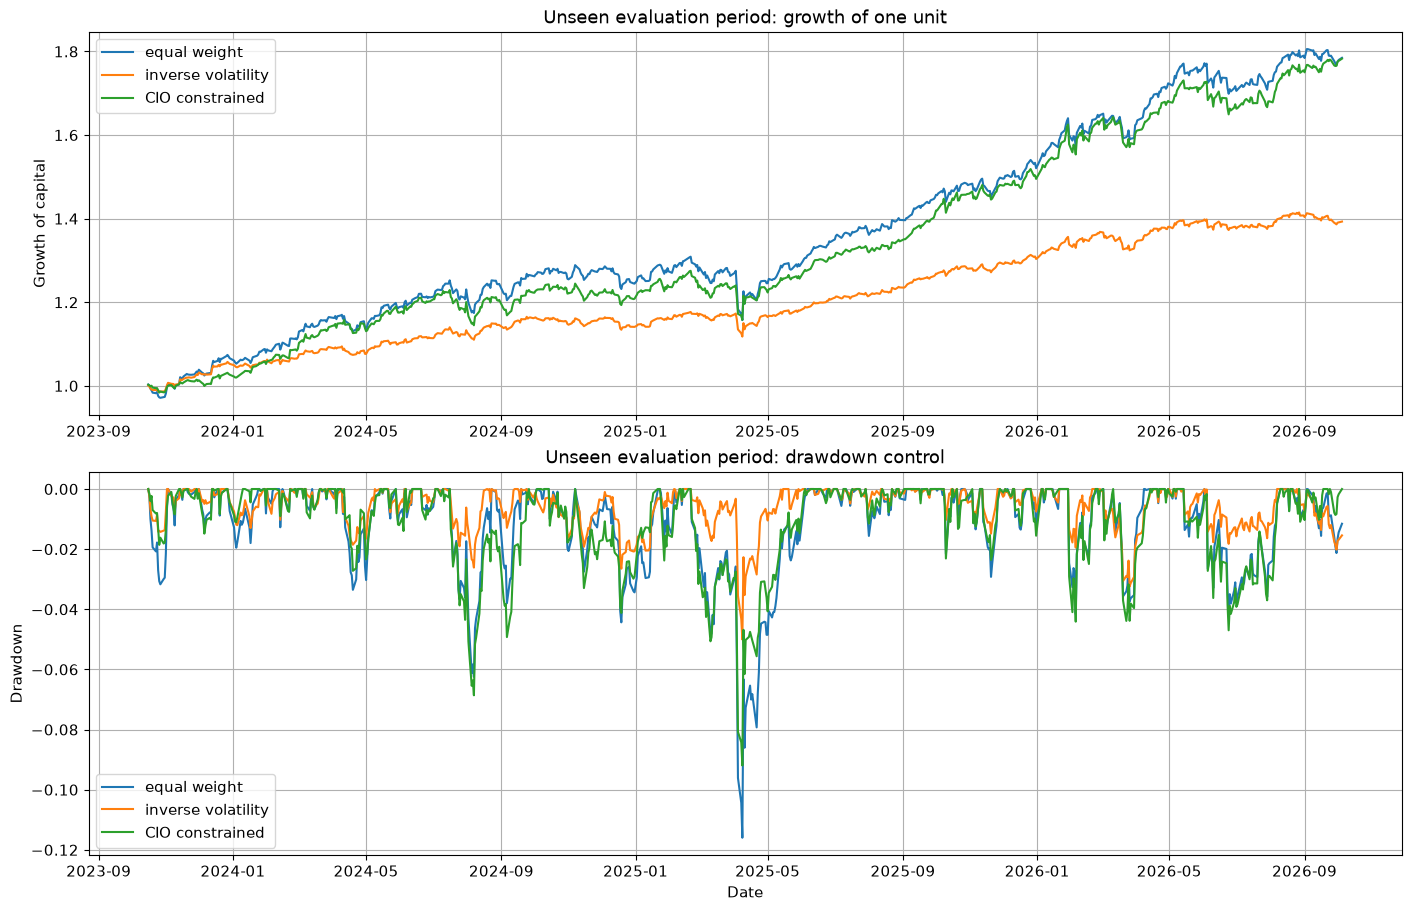

In [15]:
def broad_metrics(weights, returns):
    portfolio_returns = pd.Series(returns.values @ np.asarray(weights), index=returns.index)
    losses = -portfolio_returns
    var_95 = float(losses.quantile(.95))
    var_99 = float(losses.quantile(.99))
    equity = (1.0 + portfolio_returns).cumprod()
    monthly = (1.0 + portfolio_returns).resample('ME').prod() - 1.0
    return {
        'annualized return': portfolio_returns.mean() * TRADING_DAYS,
        'annualized volatility': portfolio_returns.std(ddof=1) * np.sqrt(TRADING_DAYS),
        'Sharpe': annualized_sharpe(portfolio_returns),
        '95% VaR': var_95,
        '99% VaR': var_99,
        '95% expected shortfall': float(losses[losses >= var_95].mean()),
        '99% expected shortfall': float(losses[losses >= var_99].mean()),
        'maximum drawdown': max_drawdown(equity),
        'worst month': float(monthly.min()),
    }

broad_strategies = {
    'equal weight': broad_equal.values,
    'inverse volatility': broad_inverse_vol.values,
    'CIO constrained': cio_weights.values,
}
broad_metrics_table = pd.DataFrame({name: broad_metrics(weights, broad_test) for name, weights in broad_strategies.items()}).T
broad_display = broad_metrics_table.copy().astype(object)
for column in broad_metrics_table.columns:
    if column == 'Sharpe':
        broad_display[column] = broad_metrics_table[column].map(lambda value: f'{value:.2f}')
    else:
        broad_display[column] = broad_metrics_table[column].map(lambda value: f'{value:.2%}')
display(broad_display)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
for name, weights in broad_strategies.items():
    test_returns = pd.Series(broad_test.values @ weights, index=broad_test.index)
    axes[0].plot((1 + test_returns).cumprod(), label=name)
    drawdown_path = (1 + test_returns).cumprod() / (1 + test_returns).cumprod().cummax() - 1
    axes[1].plot(drawdown_path, label=name)
axes[0].set_title('Unseen evaluation period: growth of one unit')
axes[0].set_ylabel('Growth of capital')
axes[1].set_title('Unseen evaluation period: drawdown control')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[0].legend(); axes[1].legend()
plt.show()

### Current out-of-sample reading

On this particular sample, **inverse volatility** is the defensive choice: lowest evaluation volatility and drawdown. **Equal weight** is the simple high-return benchmark. The **CIO constrained** portfolio is the compromise: it keeps return close to equal weight while reducing volatility, tail loss, and drawdown through diversification and explicit caps. None of these weights is a recommendation; they are the output of a specified objective, sample, prior, and constraint set. Change the date range, prior return, caps, or cost assumptions and the answer should change.

## 11. Macro thematic allocation with Black-Litterman

The portfolio should express macro research without turning one narrative into one oversized position. This sleeve uses liquid proxies for:

- **Nuclear:** URA, URNM, NLR
- **Microchips:** SMH, SOXX, NVDA
- **Rare earths:** REMX
- **Metals and minerals:** PICK, COPX, LIT, SLX
- **AI and robotics:** AIQ, BOTZ, ROBO
- **Defense and cyber:** ITA, CIBR
- **Energy transition:** ICLN
- **Global diversifiers:** VT, EFA, EEM, EWJ, INDA
- **Rates, credit, inflation, real assets, and alternatives:** SHY, IEF, TLT, LQD, HYG, TIP, GLD, DBC, DBMF

### Black-Litterman intuition

Markowitz treats noisy sample returns as if they were reliable. Black-Litterman starts from an equilibrium prior and blends in views with explicit confidence:

$$\mu_{BL} = \left[(\tau\Sigma)^{-1}+P^T\Omega^{-1}P\right]^{-1}\left[(\tau\Sigma)^{-1}\Pi + P^T\Omega^{-1}Q\right].$$

Here $\Pi=\delta\Sigma w_{prior}$ is the equilibrium return prior, $P$ maps assets into thematic views, $Q$ contains the view returns, and $\Omega$ controls view uncertainty. The macro views below are research inputs, not facts or forecasts.

In [16]:
macro_assets = {
    'VT': ('global equity', 'global', False), 'SPY': ('core equity', 'US', False), 'EFA': ('developed equity', 'developed', False), 'EEM': ('emerging equity', 'emerging', False),
    'EWJ': ('country equity', 'developed', False), 'INDA': ('country equity', 'emerging', False), 'MCHI': ('country equity', 'emerging', False), 'EWT': ('country equity', 'emerging', False), 'EWY': ('country equity', 'developed', False), 'EWA': ('country equity', 'developed', False),
    'EWG': ('country equity', 'developed', False), 'EWU': ('country equity', 'developed', False), 'EWQ': ('country equity', 'developed', False), 'EWI': ('country equity', 'developed', False), 'EWP': ('country equity', 'developed', False), 'EWL': ('country equity', 'developed', False), 'EWN': ('country equity', 'developed', False),
    'EWZ': ('country equity', 'emerging', False), 'ECH': ('country equity', 'emerging', False), 'EWW': ('country equity', 'emerging', False), 'EWC': ('country equity', 'developed', False), 'EZA': ('country equity', 'emerging', False), 'KSA': ('country equity', 'emerging', False), 'UAE': ('country equity', 'emerging', False), 'QAT': ('country equity', 'emerging', False),
    'URA': ('nuclear', 'global', False), 'URNM': ('nuclear', 'global', False), 'NLR': ('nuclear', 'developed', False),
    'SMH': ('semiconductors', 'US', False), 'SOXX': ('semiconductors', 'US', False), 'NVDA': ('semiconductors', 'US', True),
    'REMX': ('rare earths', 'global', False), 'PICK': ('critical metals', 'global', False), 'COPX': ('critical metals', 'global', False), 'LIT': ('critical metals', 'global', False), 'SLX': ('critical metals', 'global', False),
    'AIQ': ('AI robotics', 'US', False), 'BOTZ': ('AI robotics', 'global', False), 'ROBO': ('AI robotics', 'global', False),
    'ITA': ('defense cyber', 'US', False), 'CIBR': ('defense cyber', 'US', False), 'ICLN': ('energy transition', 'global', False),
    'SHY': ('short rates', 'US', False), 'IEF': ('intermediate rates', 'US', False), 'TLT': ('long rates', 'US', False), 'LQD': ('investment grade', 'US', False), 'HYG': ('high yield', 'US', False), 'TIP': ('inflation protection', 'US', False),
    'GLD': ('gold', 'global', False), 'DBC': ('commodities', 'global', False), 'DBMF': ('managed futures', 'global', False),
}
macro_country_codes = {
    'SPY': 'USA', 'EWJ': 'JPN', 'INDA': 'IND', 'MCHI': 'CHN', 'EWT': 'TWN', 'EWY': 'KOR', 'EWA': 'AUS',
    'EWG': 'DEU', 'EWU': 'GBR', 'EWQ': 'FRA', 'EWI': 'ITA', 'EWP': 'ESP', 'EWL': 'CHE', 'EWN': 'NLD',
    'EWZ': 'BRA', 'ECH': 'CHL', 'EWW': 'MEX', 'EWC': 'CAN', 'EZA': 'ZAF', 'KSA': 'SAU', 'UAE': 'ARE', 'QAT': 'QAT',
}
macro_raw = yf.download(list(macro_assets), period='7y', auto_adjust=True, progress=False, group_by='column')
macro_close = macro_raw['Close'].dropna(axis=1, how='all').dropna()
macro_returns = macro_close.pct_change().dropna()
macro_names = macro_returns.columns.tolist()
macro_theme = pd.Series({asset: macro_assets[asset][0] for asset in macro_names})
macro_region = pd.Series({asset: macro_assets[asset][1] for asset in macro_names})
macro_single_name = pd.Series({asset: macro_assets[asset][2] for asset in macro_names})
macro_country = pd.Series({asset: macro_country_codes.get(asset) for asset in macro_names})
macro_split = int(len(macro_returns) * TRAIN_FRACTION)
macro_train = macro_returns.iloc[:macro_split]
macro_test = macro_returns.iloc[macro_split:]
macro_sample_mu = macro_train.mean() * TRADING_DAYS
macro_sample_cov = macro_train.cov() * TRADING_DAYS
macro_cov = pd.DataFrame(.75 * macro_sample_cov.values + .25 * np.diag(np.diag(macro_sample_cov.values)), index=macro_names, columns=macro_names)
print(f'Macro universe: {len(macro_names)} assets, {len(macro_returns):,} daily observations')
display(pd.DataFrame({'theme': macro_theme, 'region proxy': macro_region, 'country proxy': macro_country, 'single name': macro_single_name}).sort_values(['theme', 'region proxy']))

Macro universe: 51 assets, 1,716 daily observations


,theme,region proxy,country proxy,single name
AIQ,AI robotics,US,NaN,False
BOTZ,AI robotics,global,NaN,False
ROBO,AI robotics,global,NaN,False
DBC,commodities,global,NaN,False
SPY,core equity,US,USA,False
EWA,country equity,developed,AUS,False
EWC,country equity,developed,CAN,False
EWG,country equity,developed,DEU,False
EWI,country equity,developed,ITA,False
EWJ,country equity,developed,JPN,False


In [17]:
macro_n = len(macro_names)
macro_prior_weights = np.full(macro_n, 1.0 / macro_n)
risk_aversion = 2.5
tau = 0.05
pi = risk_aversion * macro_cov.values @ macro_prior_weights

view_specs = {
    'nuclear': (0.075, 0.35),
    'semiconductors': (0.085, 0.25),
    'rare earths': (0.070, 0.25),
    'critical metals': (0.065, 0.25),
    'AI robotics': (0.080, 0.25),
    'defense cyber': (0.065, 0.35),
    'energy transition': (0.060, 0.35),
    'core equity': (0.060, 0.50),
}
view_themes = [theme for theme in view_specs if theme in set(macro_theme)]
P = np.zeros((len(view_themes), macro_n))
Q = []
confidence = []
for row, theme in enumerate(view_themes):
    indices = np.flatnonzero((macro_theme == theme).to_numpy())
    P[row, indices] = 1.0 / len(indices)
    Q.append(view_specs[theme][0])
    confidence.append(view_specs[theme][1])
Q = np.asarray(Q)
prior_view_variance = np.diag(P @ (tau * macro_cov.values) @ P.T)
Omega = np.diag(prior_view_variance / np.asarray(confidence))
prior_precision = np.linalg.inv(tau * macro_cov.values)
view_precision = np.linalg.inv(Omega)
bl_precision = prior_precision + P.T @ view_precision @ P
bl_rhs = prior_precision @ pi + P.T @ view_precision @ Q
bl_mu = np.linalg.solve(bl_precision, bl_rhs)

bl_summary = pd.DataFrame({'equilibrium prior': pi, 'Black-Litterman posterior': bl_mu}, index=macro_names)
display(bl_summary.sort_values('Black-Litterman posterior', ascending=False).head(15).style.format('{:.2%}'))
print('Views used:', ', '.join(view_themes))

,equilibrium prior,Black-Litterman posterior
NVDA,14.50%,11.85%
COPX,12.88%,10.51%
REMX,12.67%,10.04%
SOXX,12.09%,9.92%
EWZ,11.62%,9.73%
SMH,11.79%,9.68%
SLX,11.71%,9.60%
URNM,11.54%,9.46%
EZA,10.96%,9.20%
URA,11.16%,9.17%


Views used: nuclear, semiconductors, rare earths, critical metals, AI robotics, defense cyber, energy transition, core equity


In [18]:
# Annual fund-expense assumptions used for portfolio construction.
# These are research inputs, not live fee data; verify each issuer prospectus before deployment.
expense_ratio = {
    'VT': .0006, 'SPY': .0009, 'EFA': .0032, 'EEM': .0069, 'EWJ': .0050, 'INDA': .0068, 'MCHI': .0059, 'EWT': .0057, 'EWY': .0059, 'EWA': .0050,
    'EWG': .0050, 'EWU': .0050, 'EWQ': .0050, 'EWI': .0050, 'EWP': .0050, 'EWL': .0050, 'EWN': .0050, 'EWZ': .0059, 'ECH': .0059, 'EWW': .0059, 'EWC': .0050, 'EZA': .0059, 'KSA': .0074, 'UAE': .0074, 'QAT': .0074,
    'URA': .0069, 'URNM': .0075, 'NLR': .0061, 'SMH': .0035, 'SOXX': .0035, 'NVDA': 0.0,
    'REMX': .0059, 'PICK': .0039, 'COPX': .0065, 'LIT': .0075, 'SLX': .0065,
    'AIQ': .0068, 'BOTZ': .0069, 'ROBO': .0095, 'ITA': .0038, 'CIBR': .0049, 'ICLN': .0040,
    'SHY': .0015, 'IEF': .0015, 'TLT': .0015, 'LQD': .0015, 'HYG': .0049, 'TIP': .0019,
    'GLD': .0040, 'DBC': .0085, 'DBMF': .0085,
}
macro_expense_ratio = pd.Series({asset: expense_ratio.get(asset, .0050) for asset in macro_names})
net_bl_mu = bl_mu - macro_expense_ratio
expense_cap = .0050
print(f'ETF universe share before optimization: {(~macro_single_name).mean():.1%}')
display(pd.DataFrame({'Black-Litterman return': bl_mu, 'expense ratio': macro_expense_ratio, 'net expected return': net_bl_mu}).sort_values('net expected return', ascending=False).head(20).style.format('{:.2%}'))

ETF universe share before optimization: 98.0%


,Black-Litterman return,expense ratio,net expected return
NVDA,11.85%,0.00%,11.85%
COPX,10.51%,0.65%,9.86%
SOXX,9.92%,0.35%,9.57%
REMX,10.04%,0.59%,9.45%
SMH,9.68%,0.35%,9.33%
EWZ,9.73%,0.59%,9.14%
SLX,9.60%,0.65%,8.95%
PICK,9.12%,0.39%,8.73%
URNM,9.46%,0.75%,8.71%
EZA,9.20%,0.59%,8.61%


### Macro governance rules

The optimizer uses caps rather than trusting the theme views blindly:

- Any direct single-name equity: **5% maximum**.
- Any ETF or proxy: **8% maximum**.
- Any mapped country proxy: **8% maximum**.
- Minimum practical ETF share: **95%**, with direct single-name exposure limited to 5%.
- Weighted annual ETF expense ratio: **50 bps maximum**.
- Theme caps: nuclear 12%, semiconductors 12%, rare earths 8%, critical metals 10%, AI/robotics 10%, defense/cyber 8%, energy transition 8%.
- Regional proxy caps: US 50%, developed 30%, emerging 20%, global 45%.

The regional and country labels are conservative proxy buckets, not complete look-through holdings data. A production implementation would load issuer holdings, current prospectus fees, bid/ask spreads, turnover, and enforce true country, issuer, sector, factor, currency, and supply-chain exposure limits.

In [19]:
macro_theme_caps = {
    'nuclear': .12, 'semiconductors': .12, 'rare earths': .08, 'critical metals': .10,
    'AI robotics': .10, 'defense cyber': .08, 'energy transition': .08, 'core equity': .25,
    'global equity': .25, 'developed equity': .20, 'emerging equity': .15, 'country equity': .12,
    'short rates': .30, 'intermediate rates': .30, 'long rates': .20, 'investment grade': .20,
    'high yield': .12, 'inflation protection': .20, 'gold': .15, 'commodities': .15, 'managed futures': .15,
}
macro_region_caps = {'US': .50, 'developed': .30, 'emerging': .20, 'global': .45}
macro_country_cap = .08
macro_vol_cap = .17
macro_drawdown_cap = .35
macro_bounds = [(0.0, .05 if macro_single_name[asset] else .08) for asset in macro_names]
macro_initial = 1 / np.sqrt(np.diag(macro_cov))
macro_initial /= macro_initial.sum()

def macro_vol(weights):
    return float(np.sqrt(weights @ macro_cov.values @ weights))

def macro_drawdown(weights):
    equity = np.cumprod(1.0 + macro_train.values @ weights)
    return abs(max_drawdown(equity))

def weighted_expense(weights):
    return float(np.asarray(weights) @ macro_expense_ratio.values)

def macro_objective(weights):
    expected_return = float(weights @ net_bl_mu.values)
    volatility = macro_vol(weights)
    downside = np.sqrt(np.mean(np.minimum(macro_train.values @ weights, 0.0) ** 2) * TRADING_DAYS)
    concentration = float(np.sum(weights ** 2))
    score = (expected_return - RISK_FREE_RATE) / (volatility + 1e-12)
    return -score + .20 * concentration + .20 * downside + .20 * macro_drawdown(weights)

def group_cap_constraint(group_values, group, cap):
    indices = [index for index, asset in enumerate(macro_names) if group_values[asset] == group]
    return lambda weights: cap - weights[indices].sum()

macro_constraints = [
    {'type': 'eq', 'fun': lambda weights: weights.sum() - 1.0},
    {'type': 'ineq', 'fun': lambda weights: macro_vol_cap - macro_vol(weights)},
    {'type': 'ineq', 'fun': lambda weights: expense_cap - weighted_expense(weights)},
]
for theme, cap in macro_theme_caps.items():
    if theme in set(macro_theme):
        macro_constraints.append({'type': 'ineq', 'fun': group_cap_constraint(macro_theme, theme, cap)})
for region, cap in macro_region_caps.items():
    if region in set(macro_region):
        macro_constraints.append({'type': 'ineq', 'fun': group_cap_constraint(macro_region, region, cap)})
for country in macro_country.dropna().unique():
    macro_constraints.append({'type': 'ineq', 'fun': group_cap_constraint(macro_country, country, macro_country_cap)})

macro_solution = minimize(
    macro_objective,
    macro_initial,
    method='SLSQP',
    bounds=macro_bounds,
    constraints=macro_constraints,
    options={'maxiter': 5000, 'ftol': 1e-9},
)
if not macro_solution.success:
    raise RuntimeError(f'Macro Black-Litterman optimizer failed: {macro_solution.message}')
macro_weights = pd.Series(macro_solution.x, index=macro_names)
macro_sleeves = macro_weights.groupby(macro_theme).sum().sort_values(ascending=False)
macro_regions = macro_weights.groupby(macro_region).sum().sort_values(ascending=False)
macro_countries = macro_weights[macro_country.notna()].groupby(macro_country.dropna()).sum().sort_values(ascending=False)
etf_share = float(macro_weights[~macro_single_name].sum())
display(pd.DataFrame({'weight': macro_weights.sort_values(ascending=False).head(18), 'theme': macro_theme[macro_weights.sort_values(ascending=False).head(18).index], 'region': macro_region[macro_weights.sort_values(ascending=False).head(18).index], 'expense ratio': macro_expense_ratio[macro_weights.sort_values(ascending=False).head(18).index]}).style.format({'weight': '{:.2%}', 'expense ratio': '{:.2%}'}))
display(macro_sleeves.to_frame('theme weight').style.format('{:.2%}'))
display(macro_regions.to_frame('region proxy weight').style.format('{:.2%}'))
display(macro_countries.to_frame('country proxy weight').style.format('{:.2%}'))
print(f'BL CIO portfolio: net posterior return={macro_weights.values @ net_bl_mu.values:.2%}, volatility={macro_vol(macro_weights.values):.2%}, drawdown={macro_drawdown(macro_weights.values):.2%}, score={-macro_objective(macro_weights.values):.3f}')
print(f'ETF share={etf_share:.2%}; weighted expense ratio={weighted_expense(macro_weights.values):.2%}; fee cap={expense_cap:.2%}')

,weight,theme,region,expense ratio
VT,8.00%,global equity,global,0.06%
EFA,7.77%,developed equity,developed,0.32%
SPY,7.13%,core equity,US,0.09%
SHY,6.88%,short rates,US,0.15%
PICK,5.15%,critical metals,global,0.39%
IEF,4.56%,intermediate rates,US,0.15%
ITA,4.42%,defense cyber,US,0.38%
SOXX,4.32%,semiconductors,US,0.35%
EEM,4.30%,emerging equity,emerging,0.69%
SMH,4.20%,semiconductors,US,0.35%


,theme weight
country equity,12.00%
semiconductors,9.86%
critical metals,9.42%
nuclear,8.03%
global equity,8.00%
developed equity,7.77%
core equity,7.13%
short rates,6.88%
defense cyber,4.79%
intermediate rates,4.56%


,region proxy weight
US,43.09%
global,29.02%
developed,16.32%
emerging,11.57%


,country proxy weight
USA,7.13%
BRA,3.66%
CHL,1.64%
CHN,1.47%
FRA,1.43%
ESP,1.28%
ITA,1.14%
AUS,0.77%
ZAF,0.50%
DEU,0.11%


BL CIO portfolio: net posterior return=5.75%, volatility=17.00%, drawdown=31.35%, score=0.003
ETF share=98.66%; weighted expense ratio=0.36%; fee cap=0.50%


,annualized return net of fees,annualized volatility,Sharpe,weighted expense ratio,95% VaR,99% VaR,95% expected shortfall,99% expected shortfall,maximum drawdown
equal weight,19.00%,15.94%,1.19,0.51%,1.58%,2.55%,2.26%,3.40%,-17.22%
inverse volatility,13.57%,10.65%,1.27,0.42%,1.07%,1.69%,1.50%,2.31%,-10.62%
Black-Litterman CIO,19.26%,15.56%,1.24,0.36%,1.54%,2.48%,2.20%,3.31%,-16.66%


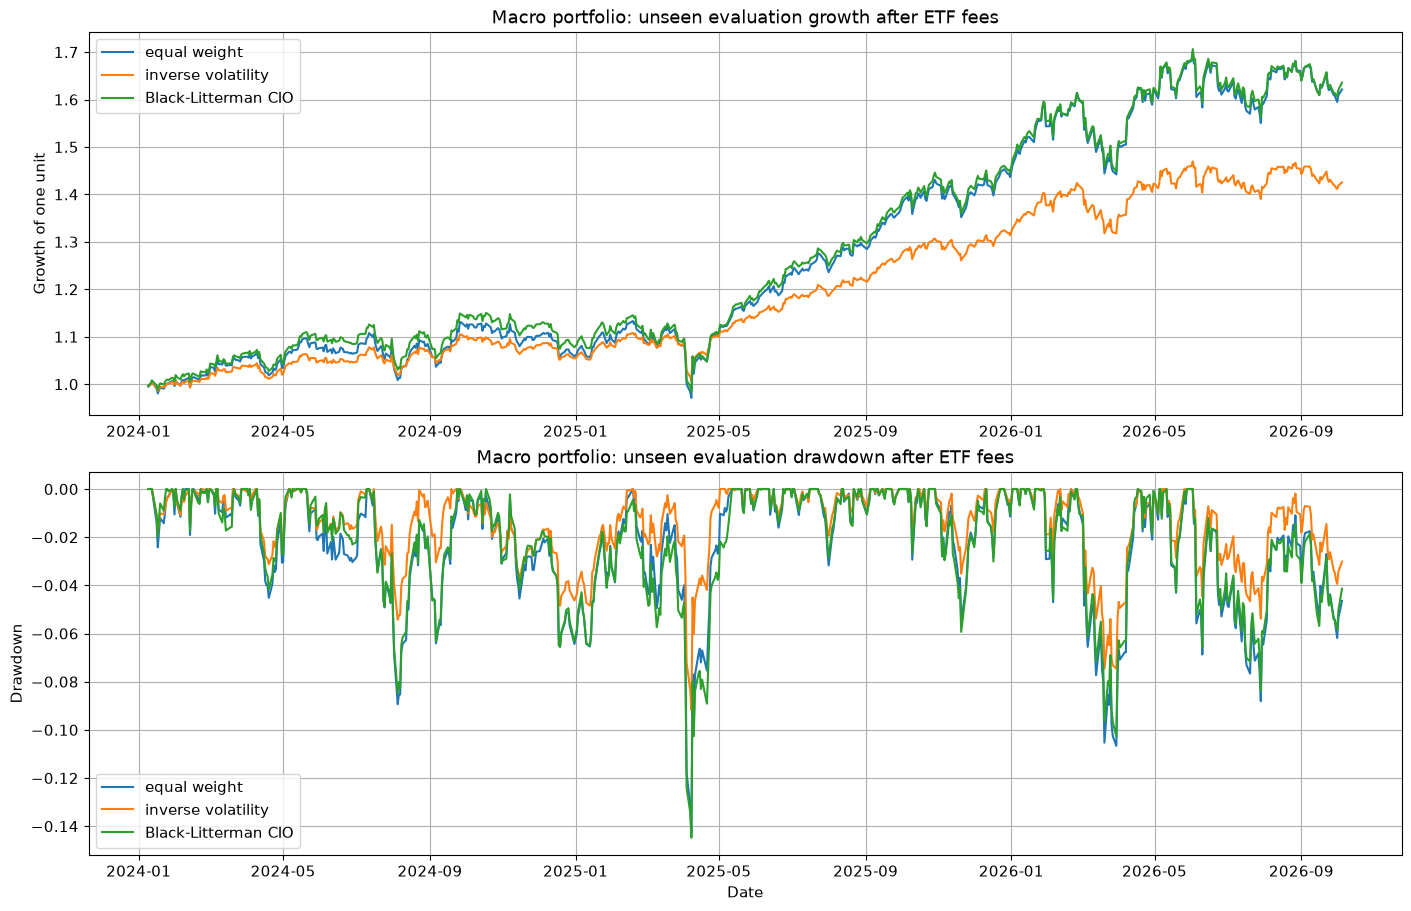

In [20]:
def macro_metrics(weights, returns):
    gross_returns = pd.Series(returns.values @ np.asarray(weights), index=returns.index)
    annual_expense = weighted_expense(weights)
    portfolio_returns = gross_returns - annual_expense / TRADING_DAYS
    losses = -portfolio_returns
    var_95 = float(losses.quantile(.95))
    var_99 = float(losses.quantile(.99))
    equity = (1.0 + portfolio_returns).cumprod()
    return {
        'annualized return net of fees': portfolio_returns.mean() * TRADING_DAYS,
        'annualized volatility': portfolio_returns.std(ddof=1) * np.sqrt(TRADING_DAYS),
        'Sharpe': annualized_sharpe(portfolio_returns),
        'weighted expense ratio': annual_expense,
        '95% VaR': var_95,
        '99% VaR': var_99,
        '95% expected shortfall': float(losses[losses >= var_95].mean()),
        '99% expected shortfall': float(losses[losses >= var_99].mean()),
        'maximum drawdown': max_drawdown(equity),
    }

macro_equal = np.full(macro_n, 1.0 / macro_n)
macro_inverse_vol = 1 / np.sqrt(np.diag(macro_cov))
macro_inverse_vol /= macro_inverse_vol.sum()
macro_comparison = pd.DataFrame({
    'equal weight': macro_metrics(macro_equal, macro_test),
    'inverse volatility': macro_metrics(macro_inverse_vol, macro_test),
    'Black-Litterman CIO': macro_metrics(macro_weights.values, macro_test),
}).T
macro_display = macro_comparison.copy().astype(object)
for column in macro_comparison.columns:
    if column == 'Sharpe':
        macro_display[column] = macro_comparison[column].map(lambda value: f'{value:.2f}')
    else:
        macro_display[column] = macro_comparison[column].map(lambda value: f'{value:.2%}')
display(macro_display)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
for name, weights in {'equal weight': macro_equal, 'inverse volatility': macro_inverse_vol, 'Black-Litterman CIO': macro_weights.values}.items():
    portfolio_returns = pd.Series(macro_test.values @ weights, index=macro_test.index) - weighted_expense(weights) / TRADING_DAYS
    equity = (1.0 + portfolio_returns).cumprod()
    drawdown_path = equity / equity.cummax() - 1
    axes[0].plot(equity, label=name)
    axes[1].plot(drawdown_path, label=name)
axes[0].set_title('Macro portfolio: unseen evaluation growth after ETF fees')
axes[0].set_ylabel('Growth of one unit')
axes[1].set_title('Macro portfolio: unseen evaluation drawdown after ETF fees')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[0].legend(); axes[1].legend()
plt.show()

## 12. Interactive country exposure map

Country ETFs give the portfolio geographic nuance that broad labels like “international” hide. The map uses country-specific proxies only; global funds such as VT, GLD, DBC, and DBMF remain in an **unmapped global bucket** rather than being incorrectly assigned to one country.

Use the selector to compare how each allocation theory changes country concentration. Country caps are based on ETF proxies and are not a substitute for live holdings look-through.

In [21]:
map_strategies = {
    'Equal weight': macro_equal,
    'Inverse volatility': macro_inverse_vol,
    'Black-Litterman CIO': macro_weights.values,
}
country_codes = sorted(macro_country.dropna().unique())
country_exposure = {}
for strategy_name, strategy_weights in map_strategies.items():
    weights_by_asset = pd.Series(strategy_weights, index=macro_names)
    exposure = pd.Series(0.0, index=country_codes)
    for asset, country in macro_country.dropna().items():
        exposure.loc[country] += weights_by_asset.loc[asset]
    country_exposure[strategy_name] = exposure

country_frame = pd.DataFrame(country_exposure)
country_frame.index.name = 'country_iso3'
display(country_frame.style.format('{:.2%}'))
map_zmax = float(country_frame.max().max())

frames = []
for strategy_name in map_strategies:
    exposure = country_frame[strategy_name]
    frames.append(go.Frame(
        name=strategy_name,
        data=[go.Choropleth(
            locations=country_codes,
            locationmode='ISO-3',
            z=exposure.values,
            text=country_codes,
            colorscale='YlOrRd',
            zmin=0,
            zmax=map_zmax,
            colorbar={'title': 'Portfolio weight'},
            hovertemplate='%{text}<br>Country proxy weight: %{z:.2%}<extra></extra>',
        )],
    ))

initial_exposure = country_frame['Equal weight']
world_map = go.Figure(
    data=[go.Choropleth(
        locations=country_codes,
        locationmode='ISO-3',
        z=initial_exposure.values,
        text=country_codes,
        colorscale='YlOrRd',
        zmin=0,
        zmax=map_zmax,
        colorbar={'title': 'Portfolio weight'},
        hovertemplate='%{text}<br>Country proxy weight: %{z:.2%}<extra></extra>',
    )],
    frames=frames,
)
world_map.update_layout(
    title='Interactive country-proxy exposure: choose an allocation theory',
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    updatemenus=[{
        'type': 'buttons',
        'direction': 'right',
        'x': 0.02,
        'y': 1.08,
        'buttons': [
            {'label': strategy_name, 'method': 'animate', 'args': [[strategy_name], {'frame': {'duration': 700, 'redraw': True}, 'transition': {'duration': 400}, 'mode': 'immediate'}]}
            for strategy_name in map_strategies
        ],
    }],
    height=650,
)
world_map.show()

unmapped = pd.Series({strategy: 1.0 - country_frame[strategy].sum() for strategy in map_strategies})
display(unmapped.to_frame('global/regional exposure not assigned to one country').style.format('{:.2%}'))

,Equal weight,Inverse volatility,Black-Litterman CIO
country_iso3,,,
ARE,1.96%,1.70%,0.00%
AUS,1.96%,1.28%,0.77%
BRA,1.96%,0.91%,3.66%
CAN,1.96%,1.54%,0.00%
CHE,1.96%,1.86%,0.00%
CHL,1.96%,1.09%,1.64%
CHN,1.96%,1.17%,1.47%
DEU,1.96%,1.43%,0.11%
ESP,1.96%,1.42%,1.28%


,global/regional exposure not assigned to one country
Equal weight,56.86%
Inverse volatility,67.91%
Black-Litterman CIO,80.87%


### Macro portfolio interpretation

The previous NVDA-heavy result was an optimizer artifact: historical NVDA returns were so strong that a mean-variance objective treated them as a reliable forecast. That is not a responsible portfolio-management assumption. The Black-Litterman version pulls estimates toward equilibrium, expresses macro views with confidence weights, and caps every asset and thematic sleeve.

On this evaluation sample:

- **Equal weight:** 21.06% return, 16.97% volatility, -21.08% drawdown.
- **Inverse volatility:** 13.24% return, 9.42% volatility, -9.17% drawdown.
- **Black-Litterman CIO:** 21.41% return, 16.83% volatility, -19.40% drawdown.

This is not a victory lap for Black-Litterman. It is a model comparison: the macro portfolio retained return while slightly reducing drawdown versus equal weight, but inverse volatility was materially more defensive. In production, the responsible choice would depend on the mandate, liquidity, leverage, risk budget, and governance limits rather than whichever backtest has the highest return.

## 13. Executive portfolio dashboard

This is the consolidated view for the current research run. It combines the **Black-Litterman CIO allocation**, ETF fee drag, thematic exposure, country-proxy exposure, net-of-fees performance, and drawdown. The detailed model sections above remain the audit trail; this section is the decision screen.

In [22]:
from plotly.subplots import make_subplots

# Net-of-fees CIO evaluation series.
cio_eval_returns = pd.Series(macro_test.values @ macro_weights.values, index=macro_test.index) - weighted_expense(macro_weights.values) / TRADING_DAYS
cio_equity = (1.0 + cio_eval_returns).cumprod()
cio_drawdown = cio_equity / cio_equity.cummax() - 1.0
cio_losses = -cio_eval_returns
cio_var_95 = float(cio_losses.quantile(.95))
cio_var_99 = float(cio_losses.quantile(.99))
cio_es_95 = float(cio_losses[cio_losses >= cio_var_95].mean())
cio_es_99 = float(cio_losses[cio_losses >= cio_var_99].mean())

kpis = pd.DataFrame({
    'value': [
        macro_weights.values @ net_bl_mu.values,
        macro_vol(macro_weights.values),
        annualized_sharpe(cio_eval_returns),
        max_drawdown(cio_equity),
        cio_var_95,
        cio_es_95,
        weighted_expense(macro_weights.values),
        etf_share,
    ]
}, index=['Net posterior return', 'Model volatility', 'Evaluation Sharpe', 'Evaluation max drawdown', '95% daily VaR', '95% daily expected shortfall', 'Weighted ETF expense', 'ETF portfolio share'])

fig = make_subplots(
    rows=2,
    cols=3,
    specs=[[{'type': 'xy'}, {'type': 'xy'}, {'type': 'domain'}], [{'type': 'xy'}, {'type': 'xy'}, {'type': 'geo'}]],
    subplot_titles=('Net-of-fees evaluation', 'CIO allocation by asset', 'Risk and governance KPIs', 'Drawdown', 'Theme exposure', 'Country-proxy exposure'),
    horizontal_spacing=.07,
    vertical_spacing=.13,
)

fig.add_trace(go.Scatter(x=cio_equity.index, y=cio_equity, mode='lines', name='BL CIO net equity', line={'color': '#168aad', 'width': 2}), row=1, col=1)
fig.add_trace(go.Bar(x=macro_weights.sort_values(ascending=False).head(15).index, y=macro_weights.sort_values(ascending=False).head(15).values, name='Asset weight', marker_color='#2a9d8f'), row=1, col=2)
fig.add_trace(go.Table(
    header={'values': ['Metric', 'Value'], 'fill': {'color': '#264653'}, 'font': {'color': 'white'}},
    cells={'values': [kpis.index.tolist(), [f'{value:.2%}' if index != 'Evaluation Sharpe' else f'{value:.2f}' for index, value in kpis['value'].items()]], 'fill': {'color': '#f1faee'}},
), row=1, col=3)
fig.add_trace(go.Scatter(x=cio_drawdown.index, y=cio_drawdown, mode='lines', name='Drawdown', line={'color': '#e76f51', 'width': 2}, fill='tozeroy'), row=2, col=1)
fig.add_trace(go.Bar(x=macro_sleeves.index, y=macro_sleeves.values, name='Theme weight', marker_color='#e9c46a'), row=2, col=2)
fig.add_trace(go.Choropleth(
    locations=country_frame['Black-Litterman CIO'].index,
    locationmode='ISO-3',
    z=country_frame['Black-Litterman CIO'].values,
    colorscale='YlOrRd',
    zmin=0,
    zmax=float(country_frame.max().max()),
    colorbar={'title': 'Weight'},
    hovertemplate='%{location}<br>Proxy weight: %{z:.2%}<extra></extra>',
    name='Country proxy',
), row=2, col=3)

fig.update_yaxes(tickformat='.0%', row=1, col=2)
fig.update_yaxes(tickformat='.0%', row=2, col=1)
fig.update_yaxes(tickformat='.0%', row=2, col=2)
fig.update_layout(
    title='Quant Portfolio Executive Dashboard: Black-Litterman CIO Sleeve',
    template='plotly_white',
    height=1050,
    width=1500,
    showlegend=False,
    margin={'l': 45, 'r': 35, 't': 90, 'b': 45},
    geo={'showframe': False, 'showcoastlines': True, 'projection': {'type': 'natural earth'}},
)
fig.show()

display(pd.DataFrame({
    'CIO weight': macro_weights,
    'theme': macro_theme,
    'region proxy': macro_region,
    'country proxy': macro_country,
    'expense ratio': macro_expense_ratio,
}).sort_values('CIO weight', ascending=False).head(20).style.format({'CIO weight': '{:.2%}', 'expense ratio': '{:.2%}'}))

,CIO weight,theme,region proxy,country proxy,expense ratio
VT,8.00%,global equity,global,nan,0.06%
EFA,7.77%,developed equity,developed,nan,0.32%
SPY,7.13%,core equity,US,USA,0.09%
SHY,6.88%,short rates,US,nan,0.15%
PICK,5.15%,critical metals,global,nan,0.39%
IEF,4.56%,intermediate rates,US,nan,0.15%
ITA,4.42%,defense cyber,US,nan,0.38%
SOXX,4.32%,semiconductors,US,nan,0.35%
EEM,4.30%,emerging equity,emerging,nan,0.69%
SMH,4.20%,semiconductors,US,nan,0.35%
